In [ ]:
#nieuwste versie 2.0
import random
import math
from mesa import Model, Agent
from mesa.space import MultiGrid
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML
import time


# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)
        # vaste basisneiging tot recyclen (normaal verdeeld)
        self.basis_recyclewaarde = min(1, max(0, random.normalvariate(0.5, 0.15)))
        self.recyclewaarde = self.basis_recyclewaarde
        self.sociale_gevoeligheid = 0
        self.recyclegedrag = False

        self.opleidingsniveau = random.choice(["laag", "midden", "hoog"])
        self.inkomen = random.choice(["laag", "midden", "hoog"])

        # Huishoudgrootte obvverdeling Nederland 2025
        self.huishoudgrootte = random.choices([1, 2, 3, 4, 5], weights=[55, 26, 9, 7, 3])[0]

        # Basis textielafval: 0,23 kg per persoon per week
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4
        self.opgespaard_textielafval = 0

        # Basis textielafval 12 kg/persoon/jaar
        self.textielafval_per_week = 0.23 * 2.10  # kg/huishouden/week
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4
        self.opgespaard_textielafval = 0

        self.weggooifrequentie = max(1, round(random.normalvariate(20, 4))) # in weken
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie hoeveelheid textielafval obv inkomen
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.8
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.2


# Agent: textielcontainer
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        self.capaciteit = 1250          # in kg (5 m³ * 250 kg/m³)
        self.vulgraad = 0
        self.ledigingsfrequentie = 52    # 1 keer per 8 weken
        self.week = 0

    def ledigen(self):
        self.vulgraad = 0


# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=90, people_per_container=46):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0
        self.week = 0
        self.drempel = 0.5

        # aantal containers berekenen
        num_containers = math.ceil(num_people / people_per_container)

        # check of alles op het grid past
        totaal_agents = num_people + num_containers
        totaal_cellen = width * height
        if totaal_agents > totaal_cellen:
            raise ValueError(
                f"Te veel agents voor het grid: {totaal_agents} agents voor {totaal_cellen} cellen."
            )

        # alle gehele coördinaten op het grid
        beschikbare_posities = [(x, y) for x in range(width) for y in range(height)]
        random.shuffle(beschikbare_posities)

        # containers plaatsen
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(c, pos)
            self.containers.append(c)

        # huishoudens plaatsen
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(h, pos)
            self.huishoudens.append(h)

        # eerste berekening
        self.bereken_recyclegedrag()

    def next_id(self):
        self.id += 1
        return self.id

    # Manhattan-afstand op het grid
    def manhattan_afstand(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    # dichtstbijzijnde container
    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    # buurinvloed berekenen:
    # +0.1 voor buur die recycelt
    # -0.1 voor buur die niet recycelt
    def bereken_buurinvloed(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [
            (x - 1, y),  # links
            (x + 1, y),  # rechts
            (x, y - 1),  # onder
            (x, y + 1)   # boven
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        if agent.recyclegedrag:
                            buurinvloed += 0.1
                        else:
                            buurinvloed -= 0.1

        return aantal_buren, buurinvloed

    # recyclegedrag bepalen
    def bereken_recyclegedrag(self):
        for huishouden in self.huishoudens:
            # basis startwaarde recycle gedrag
            huishouden.recyclewaarde = huishouden.basis_recyclewaarde

            # buurinvloed
            aantal_buren, buurinvloed = self.bereken_buurinvloed(huishouden)
            huishouden.sociale_gevoeligheid = aantal_buren

            # afstand tot dichtstbijzijnde container
            container, afstand = self.dichtstbijzijnde_container(huishouden)
            huishouden.afstand = afstand

            # als huishouden direct naast een container woont -> altijd recyclen
            if afstand == 1:
                huishouden.recyclewaarde = self.drempel + 1
                huishouden.recyclegedrag = True
                continue

            # invloed buren
            huishouden.recyclewaarde += buurinvloed

            # invloed afstand
            huishouden.recyclewaarde -= afstand * 0.025

            # invloed inkomen
            if huishouden.inkomen == "hoog":
                huishouden.recyclewaarde += 0.1
            elif huishouden.inkomen == "laag":
                huishouden.recyclewaarde -= 0.1

            # beslissing
            huishouden.recyclegedrag = huishouden.recyclewaarde > self.drempel

    # simulatiestap
    def stap(self):
        self.week += 4

        # huishoudens produceren textielafval
        for huishouden in self.huishoudens:
            huishouden.opgespaard_textielafval += huishouden.textielafval_per_tijdstap
            huishouden.weken_tot_weggooien -= 4

        # recyclegedrag opnieuw berekenen
        self.bereken_recyclegedrag()

        # textiel weggooien
        for huishouden in self.huishoudens:
            if huishouden.weken_tot_weggooien <= 0:
                if huishouden.recyclegedrag:
                    container, afstand = self.dichtstbijzijnde_container(huishouden)

                    if container.vulgraad + huishouden.opgespaard_textielafval <= container.capaciteit:
                        container.vulgraad += huishouden.opgespaard_textielafval
                    else:
                        container.vulgraad = container.capaciteit

                huishouden.opgespaard_textielafval = 0
                huishouden.weken_tot_weggooien = huishouden.weggooifrequentie

        # containers legen elke 8 weken
        if self.week % 52 == 0:
            for container in self.containers:
                container.ledigen()

    # resultaten weergeven
    def resultaten(self):
        print("\nRESULTATEN:\n")

        print(f"{'Huishouden':<12} {'Grootte':<8} {'Positie':<12} {'Buren':<6} {'Opleiding':<10} {'Inkomen':<10} {'Afstand':<10} {'Opgespaard':<12} {'Recyclewaarde':<16} {'Recyclegedrag':<10}")
        print("-" * 130)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{huishouden.huishoudgrootte:<8} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.opleidingsniveau:<10} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.opgespaard_textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{str(huishouden.recyclegedrag):<10}"
            )


# simulatie
for week in range(4):
    print(f"\nWEEK {week + 1}")
    model.stap()
    model.visualiseer()
    model.resultaten()

model = Stad()

fig, ax = plt.subplots(figsize=(7,7))

model model = Stad(width=10, height=10, num_people=90, people_per_container=46) # simulatie for week in range(4): print(f"\nWEEK {week + 1}") model.stap() model.visualiseer() model.resultaten() model = Stad() fig, ax = plt.subplots(figsize=(7,7)) # startbeeld model.visualiseer(ax) def update(frame): model.stap() model.visualiseer(ax) anim = FuncAnimation( fig, update, frames=20, interval=1000, repeat=False, cache_frame_data=False ) # 👉 werkt in notebook from IPython.display import HTML HTML(anim.to_jshtml())


In [ ]:
#nieuwste versie 2.0
import random
import math
from mesa import Model, Agent
from mesa.space import MultiGrid
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML
import time


# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)
        # vaste basisneiging tot recyclen (normaal verdeeld)
        self.basis_recyclewaarde = min(1, max(0, random.normalvariate(0.5, 0.15)))
        self.recyclewaarde = self.basis_recyclewaarde
        self.sociale_gevoeligheid = 0
        self.recyclegedrag = False

        self.opleidingsniveau = random.choice(["laag", "midden", "hoog"])
        self.inkomen = random.choice(["laag", "midden", "hoog"])

        # Huishoudgrootte obvverdeling Nederland 2025
        self.huishoudgrootte = random.choices([1, 2, 3, 4, 5], weights=[55, 26, 9, 7, 3])[0]

        # Basis textielafval: 0,23 kg per persoon per week
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4
        self.opgespaard_textielafval = 0

        # Basis textielafval 12 kg/persoon/jaar
        self.textielafval_per_week = 0.23 * 2.10  # kg/huishouden/week
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4
        self.opgespaard_textielafval = 0

        self.weggooifrequentie = max(1, round(random.normalvariate(20, 15))) # in weken
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie hoeveelheid textielafval obv inkomen
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.8
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.2

# Agent: textielcontainer
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        self.capaciteit = 1250          # in kg (5 m³ * 250 kg/m³)
        self.vulgraad = 0
        self.ledigingsfrequentie = 52    # 1 keer per 8 weken
        self.week = 0

    def ledigen(self):
        self.vulgraad = 0


# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=90, people_per_container=46):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0
        self.week = 0
        self.drempel = 0.5

        # aantal containers berekenen
        num_containers = math.ceil(num_people / people_per_container)

        # check of alles op het grid past
        totaal_agents = num_people + num_containers
        totaal_cellen = width * height
        if totaal_agents > totaal_cellen:
            raise ValueError(
                f"Te veel agents voor het grid: {totaal_agents} agents voor {totaal_cellen} cellen."
            )

        # alle gehele coördinaten op het grid
        beschikbare_posities = [(x, y) for x in range(width) for y in range(height)]
        random.shuffle(beschikbare_posities)

        # containers plaatsen
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(c, pos)
            self.containers.append(c)

        # huishoudens plaatsen
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(h, pos)
            self.huishoudens.append(h)

        # eerste berekening
        self.bereken_recyclegedrag()

    midden_x = width // 2
    midden_y = height // 2

    wijk_posities = {
        "rijk_centrum": [(x, y) for x in range(0, midden_x) for y in range(midden_y, height)],
        "rijk_rand": [(x, y) for x in range(midden_x, width) for y in range(midden_y, height)],
        "arm_centrum": [(x, y) for x in range(0, midden_x) for y in range(0, midden_y)],
        "arm_rand": [(x, y) for x in range(midden_x, width) for y in range(0, midden_y)],
    }

    def next_id(self):
        self.id += 1
        return self.id

    def manhattan_afstand(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    def bereken_buurinvloed(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [(x - 1, y),(x + 1, y),(x, y - 1),(x, y + 1)]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])
                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        buurinvloed += 0.1 if agent.recyclegedrag else -0.1

        return aantal_buren, buurinvloed

    def bereken_recyclegedrag(self):
        for huishouden in self.huishoudens:
            huishouden.recyclewaarde = huishouden.basis_recyclewaarde
            aantal_buren, buurinvloed = self.bereken_buurinvloed(huishouden)
            huishouden.sociale_gevoeligheid = aantal_buren
            container, afstand = self.dichtstbijzijnde_container(huishouden)
            huishouden.afstand = afstand

            if afstand == 1:
                huishouden.recyclegedrag = True
                continue

            huishouden.recyclewaarde += buurinvloed
            huishouden.recyclewaarde -= afstand * 0.025

            if huishouden.inkomen == "hoog":
                huishouden.recyclewaarde += 0.1
            elif huishouden.inkomen == "laag":
                huishouden.recyclewaarde -= 0.1

            huishouden.recyclegedrag = huishouden.recyclewaarde > self.drempel

    def stap(self):
        self.week += 4

        for huishouden in self.huishoudens:
            huishouden.opgespaard_textielafval += huishouden.textielafval_per_tijdstap
            huishouden.weken_tot_weggooien -= 4

        self.bereken_recyclegedrag()

        for huishouden in self.huishoudens:
            if huishouden.weken_tot_weggooien <= 0:
                if huishouden.recyclegedrag:
                    container, _ = self.dichtstbijzijnde_container(huishouden)
                    container.vulgraad = min(container.capaciteit,
                                              container.vulgraad + huishouden.opgespaard_textielafval)
                huishouden.opgespaard_textielafval = 0
                huishouden.weken_tot_weggooien = huishouden.weggooifrequentie

        if self.week % 52 == 0:
            for container in self.containers:
                container.ledigen()

    #AANGEPAST: visualisatie werkt nu met en zonder ax
    def visualiseer(self, ax=None):
        if ax is None:
            plt.figure(figsize=(7, 7))
            ax = plt.gca()
        else:
            ax.clear()

        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            grootte_bol = h.huishoudgrootte * 40
            ax.scatter(x, y, color=kleur, s=grootte_bol)
            ax.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            ax.scatter(x, y, color="green", s=100, marker="s")
            ax.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        ax.grid()
        ax.set_title("Stad met huishoudens en textielcontainers")
        ax.set_xlim(-0.5, self.grid.width - 0.5)
        ax.set_ylim(-0.5, self.grid.height - 0.5)
        ax.set_xticks(range(self.grid.width))
        ax.set_yticks(range(self.grid.height))

        if ax is plt.gca():
            plt.show()


# model
model = Stad(width=10, height=10, num_people=90, people_per_container=46)

for week in range(4):
    print(f"\nWEEK {week + 1}")
    model.stap()
    model.visualiseer()

model = Stad()

fig, ax = plt.subplots(figsize=(7,7))
model.visualiseer(ax)

def update(frame):
    model.stap()
    model.visualiseer(ax)

anim = FuncAnimation(fig, update, frames=20, interval=1000, repeat=False)
HTML(anim.to_jshtml())

In [ ]:
import math
import random
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


# ============================================================
# AGENT: HUISHOUDEN
# ============================================================
class Huishouden(Agent):
    """
    Een huishouden is een agent die de volgende parameters bevat: (huishoudgrootte, opbouwen van textielafval, wordt beinvloed door buren, recyclewaarde, brengt textiel weg naar dichtsbijzijnde container)

    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # elk huishouden krijgt een basis recyclewaarde, deze waarde bepaald of een huishouden in het begin al recycelt of niet. Deze waarde ligt tussen 0 en 1, wij hebben nu de drempelwaarde even op 0.5 gezet.
        self.basis_recyclewaarde = min(1, max(0, self.model.random.normalvariate(0.5, 0.15)))

        # De actuele recyclewaarde van een huishouden wordt elke stap opnieuw berekend.
        self.recyclewaarde = self.basis_recyclewaarde

        # Aantal directe buren dat meetelt in de buurinvloed.
        self.sociale_gevoeligheid = 0

        # recyclet het huishouden op dit moment wel of niet
        self.recyclegedrag = False

        # maakt duidelijk of een huishouden wel of niet recycelt.
        self.status = "recycleert_niet"

        #naar waarden van cbs
        self.opleidingsniveau = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.262,0.372, 0.366])[0]
        #naar waarden van cbs
        self.inkomen = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.140,0.556,0.304])[0]

        #hier iets met eigen mileubewustzijn of beinvloedingswaarde
        #dit doet verder nu nog helemaal niks want dit moet gekoppelt worden aan campange
        self.bemoeien_overheid_milieu=self.model.random.choices(['belangrijk','neutraal','onbelangrijk'],weights=[0.847,0.113,0.04])[0]

        #naar waarden van cbs
        self.huishoudgrootte = self.model.random.choices(
            [1, 2, 3, 4, 5],
            weights=[55, 26, 9, 7, 3]
        )[0]

        # Basis textielafval:
        # 0,23 kg per persoon per week.
        # Omdat 1 stap = 4 weken, vermenigvuldigen we met 4.
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4

        # Hoeveel textiel een huishouden momenteel opgespaard heeft.
        self.opgespaard_textielafval = 0

        # Weggooifrequentie in weken.
        # Dit geeft aan na hoeveel weken een huishouden zijn opgespaard textiel wegbrengt.
        self.weggooifrequentie = max(1, round(self.model.random.normalvariate(20, 15)))
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie op hoeveelheid textielafval op basis van inkomen.

        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.6
        elif self.inkomen == "midden":
            self.textielafval_per_tijdstap *= 1.0
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.7


        # Afstand tot dichtstbijzijnde container.
        self.afstand = None

        # Houdt bij hoeveel kg dit huishouden in totaal opgeslagen heeft.
        self.totaal_opgeslagen = 0

        # Houdt bij hoeveel kg dit huishouden in totaal gerecycled heeft.
        self.totaal_gerecycled = 0

    def update_recyclegedrag(self):

        # Start telkens opnieuw vanaf de vaste basisneiging.
        self.recyclewaarde = self.basis_recyclewaarde

        # Haal buurinvloed op uit het model.
        aantal_buren, buurinvloed = self.model.bereken_buurinvloed(self)
        self.sociale_gevoeligheid = aantal_buren

        # Bepaal dichtstbijzijnde container en afstand.
        container, afstand = self.model.dichtstbijzijnde_container(self)
        self.afstand = afstand

        # Invloed van buren.
        self.recyclewaarde += buurinvloed

        # grotere afstand tot containers samengaat met minder recycling
        #maximale dat een actor kan lopen is lengte+breedte aan hokjes
        # - dicht bij container  -> kleine positieve correctie
        # - gemiddelde afstand   -> geen correctie
        # - ver van container    -> kleine negatieve correctie

        max_afstand = (self.model.grid.width-1) + (self.model.grid.height-1)
        rel_afstand = afstand / max_afstand

        if rel_afstand <= 0.2:
            self.recyclewaarde += 0.05
        elif rel_afstand <= 0.4:
            self.recyclewaarde += 0.00
        elif rel_afstand <= 0.6:
            self.recyclewaarde -= 0.05
        else:
            self.recyclewaarde -= 0.10


        # Invloed van inkomen op basis van Viscusi, Huber & Bell (2023)
        # - grote inkomensstijging: ongeveer -1%
        # - grote inkomensdaling: ongeveer -3%

        if self.inkomen == "hoog":
            self.recyclewaarde -= 0.01
        elif self.inkomen == "laag":
            self.recyclewaarde -= 0.03

        # Zorg dat de waarde netjes tussen 0 en 1 blijft.
        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Drempelwaarde:
        # vanaf 0.5 recyclet het huishouden.
        self.recyclegedrag = self.recyclewaarde >= self.model.drempel

        # Tekststatus voor interpretatie en visualisatie.
        if self.recyclegedrag:
            self.status = "recycleert"
        else:
            self.status = "recycleert_niet"

    def produceer_textiel(self):
        """
        Voegt per stap nieuw textielafval toe aan het huishouden.
        """
        self.opgespaard_textielafval += self.textielafval_per_tijdstap
        self.totaal_opgeslagen += self.textielafval_per_tijdstap
        self.model.aangeboden_deze_stap += self.textielafval_per_tijdstap

    def probeer_textiel_weg_te_brengen(self):
        """
        Als het huishouden aan de beurt is om textiel weg te brengen:
        - en het recyclet, dan gaat het textiel naar de dichtstbijzijnde container
        - wat niet in de container past, wordt geregistreerd als niet gerecycled door capaciteitsgebrek
        - als het huishouden niet recyclet, verdwijnt het uit het systeem als niet gerecycled

        Daarna wordt het opgespaarde textiel leeggemaakt en de teller opnieuw ingesteld.
        """
        if self.weken_tot_weggooien <= 0:
            aangeboden_hoeveelheid = self.opgespaard_textielafval
            self.model.aangeboden_deze_stap += aangeboden_hoeveelheid

        if self.recyclegedrag:
            container, _ = self.model.dichtstbijzijnde_container(self)

            # Beschikbare ruimte in de container
            ruimte_over = max(0, container.capaciteit - container.vulgraad)

            # Deel dat echt gerecycled kan worden
            hoeveelheid_te_recyclen = min(ruimte_over, aangeboden_hoeveelheid)

            # Deel dat niet meer in de container past
            hoeveelheid_niet_gerecycled_door_capaciteit = aangeboden_hoeveelheid - hoeveelheid_te_recyclen

            # Voeg gerecycled deel toe aan container
            container.vulgraad += hoeveelheid_te_recyclen

            # Houd modeluitkomsten bij
            self.totaal_gerecycled += hoeveelheid_te_recyclen
            self.model.gerecycled_deze_stap += hoeveelheid_te_recyclen
            self.model.niet_gerecycled_door_capaciteit_deze_stap += hoeveelheid_niet_gerecycled_door_capaciteit

            # Per huishoudgrootte
            self.model.gerecycled_per_huishoudgrootte[self.huishoudgrootte] += hoeveelheid_te_recyclen
            self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid

            # Per inkomen
            self.model.gerecycled_per_huishoudinkomen[self.inkomen] += hoeveelheid_te_recyclen
            self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid

            # Per opleidingsniveau
            self.model.gerecycled_per_opleidingsniveau[self.opleidingsniveau] += hoeveelheid_te_recyclen
            self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

        else:
            # Huishouden biedt wel textiel aan, maar recyclet niet
            self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid
            self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid
            self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

        # Alles is uit huis verdwenen: niets wordt bewaard
        self.opgespaard_textielafval = 0

        # Teller opnieuw instellen
        self.weken_tot_weggooien = self.weggooifrequentie

    def step(self):
        """
        Eén stap van een huishouden:
        1. textiel produceren
        2. tijd tot weggooien verlagen
        3. recyclegedrag opnieuw berekenen
        4. eventueel textiel wegbrengen
        """
        self.produceer_textiel()
        self.weken_tot_weggooien -= 4
        self.update_recyclegedrag()
        self.probeer_textiel_weg_te_brengen()


# ============================================================
# AGENT: CONTAINER
# ============================================================
class Container(Agent):
    """
    Een textielcontainer heeft:
    - een maximale capaciteit
    - een actuele vulgraad
    - een methode om geleegd te worden
    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # Capaciteit in kg.
        self.capaciteit = 750

        # Huidige hoeveelheid textiel in de container.
        self.vulgraad = 0

        # Iedere 8 weken wordt de container geleegd.
        self.ledigingsfrequentie = 52

    def ledigen(self):
        """
        Zet de vulgraad terug op 0.
        """
        self.vulgraad = 0


# ============================================================
# MODEL: STAD
# ============================================================
class Stad(Model):
    """
    Het model bevat:
    - een grid met huishoudens en containers
    - logica voor buurinvloed en afstand
    - een centrale stapfunctie
    - opslag van resultaten voor grafieken
    """

    def __init__(self, width=10, height=10, num_people=90, people_per_container=10, seed=42):
        super().__init__()

        # Gebruik de randomgenerator van het model,
        # zodat simulaties reproduceerbaar zijn.
        self.random.seed(seed)

        # Het grid van de stad.
        self.grid = MultiGrid(width, height, torus=False)

        # Lijsten met agents.
        self.huishoudens = []
        self.containers = []

        # Interne ID-teller.
        self.id = 0

        # Tijd in weken.
        self.week = 0

        # Drempelwaarde voor recyclen.
        self.drempel = 0.5

        # Variabelen die per stap opnieuw worden gevuld.
        self.opgeslagen_deze_stap = 0
        self.gerecycled_deze_stap = 0

        # Resultaten doorheen de tijd.
        self.geschiedenis_weken = [0]
        self.opgeslagen_per_stap = [0]
        self.gerecycled_per_stap = [0]
        self.percentage_gerecycled_per_stap = [0]
        self.percentage_huishoudens_dat_recyclet = [0]
        self.geschiedenis_container_vulgraden = []

        # Uitkomsten per huishoudgrootte.
        self.aangeboden_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudinkomen={"laag":0,"midden":0,"hoog":0}
        self.aangeboden_per_huishoudinkomen={"laag":0,"midden":0,"hoog":0}
        self.opgeslagen_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}
        self.gerecycled_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}

        # Aantal containers op basis van people_per_container.
        num_containers = math.ceil(num_people / people_per_container)

       bezette_posities = set()

        for wijknaam, info in self.wijken.items():
            mogelijke_posities = wijk_posities[wijknaam][:]

            nodig = info["aantal_huishoudens"] + info["aantal_containers"]
            if nodig > len(mogelijke_posities):
                raise ValueError(f"Te veel agents voor wijk {wijknaam}")

            gekozen_posities = self.random.sample(mogelijke_posities, nodig)

            container_posities = gekozen_posities[:info["aantal_containers"]]
            huishouden_posities = gekozen_posities[info["aantal_containers"]:]

            for pos in container_posities:
                c = Container(self.next_id(), self)
                c.wijk = wijknaam
                self.grid.place_agent(c, pos)
                self.containers.append(c)

            for pos in huishouden_posities:
                h = Huishouden(self.next_id(), self)
                h.wijk = wijknaam
                h.wijk_inkomen_profiel = info["inkomen_profiel"]
                h.wijk_dichtheid = info["dichtheid"]
                self.grid.place_agent(h, pos)
                self.huishoudens.append(h)

        # Eerste berekening van gedrag.
        for huishouden in self.huishoudens:
            huishouden.update_recyclegedrag()

        # Startwaarden voor containergeschiedenis.
        self.geschiedenis_container_vulgraden.append(
            [container.vulgraad for container in self.containers]
        )

    def next_id(self):
        """
        Geeft elke agent een uniek ID.
        """
        self.id += 1
        return self.id

    def manhattan_afstand(self, pos1, pos2):
        """
        Bereken Manhattan-afstand tussen twee posities op het grid.
        """
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def dichtstbijzijnde_container(self, huishouden):
        """
        Zoek de dichtstbijzijnde container voor een huishouden.
        Geeft zowel de container als de afstand terug.
        """
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    def bereken_buurinvloed(self, huishouden):
        """
        Bereken buurinvloed op basis van de 4 directe buren.
        - +0.1 per buur die recyclet
        - -0.1 per buur die niet recyclet
        """
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [
            (x - 1, y),  # links
            (x + 1, y),  # rechts
            (x, y - 1),  # onder
            (x, y + 1)   # boven
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        if agent.recyclegedrag:
                            buurinvloed += 0.05
                        else:
                            buurinvloed -= 0.05

        return aantal_buren, buurinvloed

    def verzamel_resultaten(self):
        """
        Sla per stap de belangrijkste resultaten op,
        zodat die later geplot kunnen worden.
        """
        self.geschiedenis_weken.append(self.week)
        self.opgeslagen_per_stap.append(self.opgeslagen_deze_stap)
        self.gerecycled_per_stap.append(self.gerecycled_deze_stap)

        # Percentage gerecycled in deze stap.
        if self.opgeslagen_deze_stap > 0:
            percentage = (self.gerecycled_deze_stap / self.opgeslagen_deze_stap) * 100
        else:
            percentage = 0
        self.percentage_gerecycled_per_stap.append(percentage)

        # Percentage huishoudens dat op dat moment recyclet.
        aantal_recyclers = sum(1 for h in self.huishoudens if h.recyclegedrag)
        percentage_recyclers = (aantal_recyclers / len(self.huishoudens)) * 100
        self.percentage_huishoudens_dat_recyclet.append(percentage_recyclers)

        # Sla container-vulgraden op.
        self.geschiedenis_container_vulgraden.append(
            [container.vulgraad for container in self.containers]
        )

    def step(self):
        """
        Eén modelstap:
        1. tijd vooruit zetten met 4 weken
        2. stap van elk huishouden uitvoeren
        3. containers legen indien nodig
        4. resultaten opslaan
        """
        self.week += 4

        # Reset stapvariabelen.
        self.opgeslagen_deze_stap = 0
        self.gerecycled_deze_stap = 0

        # Laat elk huishouden zijn eigen gedrag uitvoeren.
        for huishouden in self.huishoudens:
            huishouden.step()

        # Ledig alle containers elke 24 weken.
        if self.week % 52 == 0:
            for container in self.containers:
                container.ledigen()

        # Verzamel resultaten voor grafieken.
        self.verzamel_resultaten()

    def visualiseer(self, ax=None):
        """
        Teken het grid.
        - Blauwe huishoudens recyclen
        - Rode huishoudens recyclen niet
        - Groene vierkanten zijn containers
        - Grootte van de huishoudensymbolen hangt af van huishoudgrootte
        """
        if ax is None:
            plt.figure(figsize=(7, 7))
            ax = plt.gca()
        else:
            ax.clear()

        # Huishoudens tekenen.
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            grootte_bol = h.huishoudgrootte * 40
            ax.scatter(x, y, color=kleur, s=grootte_bol)
            ax.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        # Containers tekenen.
        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            ax.scatter(x, y, color="green", s=120, marker="s")
            ax.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        # Layout.
        ax.grid()
        ax.set_title(f"Week {self.week} | Huishoudens en textielcontainers")
        ax.set_xlim(-0.5, self.grid.width - 0.5)
        ax.set_ylim(-0.5, self.grid.height - 0.5)
        ax.set_xticks(range(self.grid.width))
        ax.set_yticks(range(self.grid.height))
        ax.set_aspect("equal")

        if ax is plt.gca():
            plt.show()

    def resultaten(self):
        """
        Print een overzicht van de huidige toestand van elk huishouden.
        """
        print("\nRESULTATEN:\n")

        print(
            f"{'Huishouden':<12} {'Grootte':<8} {'Positie':<12} {'Buren':<6} "
            f"{'Inkomen':<10}  {'Afstand':<10} "
            f"{'Opgespaard':<12} {'Recyclewaarde':<16} {'Status':<18}"
        )
        print("-" * 130)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{huishouden.huishoudgrootte:<8} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.opgespaard_textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{huishouden.status:<18}"
            )

    # ========================================================
    # GRAFIEKEN
    # ========================================================

    def plot_totale_kg_opgeslagen_vs_gerecycled(self):
        """
        Relevante grafiek 1:
        laat per stap zien hoeveel textiel opgeslagen en gerecycled is.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.opgeslagen_per_stap, marker="o", label="Opgeslagen (kg)")
        plt.plot(self.geschiedenis_weken, self.gerecycled_per_stap, marker="o", label="Gerecycled (kg)")
        plt.xlabel("Week")
        plt.ylabel("Textiel (kg)")
        plt.title("opgeslagen versus gerecyclede hoeveelheid textiel per stap")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_percentage_gerecycled_over_tijd(self):
        """
        Relevante grafiek 2:
        laat zien welk percentage van het opgeslagen textiel gerecycled wordt.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_gerecycled_per_stap, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage van opgeslagen textiel dat gerecycled wordt")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_percentage_huishoudens_dat_recyclet(self):
        """
        Relevante grafiek 3:
        laat zien welk aandeel van de huishoudens op een bepaald moment recyclet.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_huishoudens_dat_recyclet, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Huishoudens die recyclen (%)")
        plt.title("Percentage huishoudens dat recyclet over tijd")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_container_vulgraden(self):
        """
        Relevante grafiek 4:
        toont hoe de vulgraad van elke container evolueert.
        """
        plt.figure(figsize=(12, 6))

        for i in range(len(self.containers)):
            vulgraden_i = [stap[i] for stap in self.geschiedenis_container_vulgraden]
            plt.plot(self.geschiedenis_weken, vulgraden_i, marker="o", label=f"Container {i+1}")

        plt.xlabel("Week")
        plt.ylabel("Vulgraad (kg)")
        plt.title("Vulgraad van elke container over tijd")
        plt.ylim(0, 750)
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 5:
        deze grafiek past heel goed bij jouw onderzoeksvraag.
        Ze laat zien hoeveel kg textiel gerecycled werd per huishoudgrootte.
        """
        groottes = list(self.gerecycled_per_huishoudgrootte.keys())
        waarden = list(self.gerecycled_per_huishoudgrootte.values())

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, waarden)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Totaal gerecycled textiel (kg)")
        plt.title("Totaal gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 6:
        toont per huishoudgrootte welk percentage van het opgeslagen textiel gerecycled werd.
        Dit is inhoudelijk heel relevant voor jouw onderzoek.
        """
        groottes = [1, 2, 3, 4, 5]
        percentages = []

        for grootte in groottes:
            opgeslagen = self.aangeboden_per_huishoudgrootte[grootte]
            gerecycled = self.gerecycled_per_huishoudgrootte[grootte]

            if opgeslagen > 0:
                percentages.append((gerecycled / opgeslagen) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, percentages)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_inkomen(self):
        """
        Toont per inkomenscategorie welk percentage van het opgeslagen
        textiel gerecycled werd.
        """
        inkomens = ["laag", "midden", "hoog"]
        percentages = []

        for inkomen in inkomens:
            opgeslagen = self.aangeboden_per_huishoudinkomen[inkomen]
            gerecycled = self.gerecycled_per_huishoudinkomen[inkomen]

            if opgeslagen > 0:
                percentages.append((gerecycled / opgeslagen) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(inkomens, percentages)
        plt.xlabel("Inkomenscategorie")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per inkomenscategorie")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_opleidingsniveau(self):
        """
        Toont per opleidingsniveau welk percentage van het opgeslagen
        textiel gerecycled werd.
        """
        niveaus = ["laag", "midden", "hoog"]
        percentages = []

        for niveau in niveaus:
            opgeslagen = self.opgeslagen_per_opleidingsniveau[niveau]
            gerecycled = self.gerecycled_per_opleidingsniveau[niveau]

            if opgeslagen > 0:
                percentages.append((gerecycled / opgeslagen) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(niveaus, percentages)
        plt.xlabel("Opleidingsniveau")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per opleidingsniveau")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

# ============================================================
# MODEL DRAAIEN
# ============================================================

# Maak één model aan.
model = Stad(width=10, height=10, num_people=90, people_per_container=10, seed=42)

# Draai de simulatie voor 20 stappen.
for _ in range(20):
    model.step()

# Print enkele samenvattende resultaten.
totaal_opgeslagen = sum(model.opgeslagen_per_stap)
totaal_gerecycled = sum(model.gerecycled_per_stap)

if totaal_opgeslagen > 0:
    totaal_percentage = (totaal_gerecycled / totaal_opgeslagen) * 100
else:
    totaal_percentage = 0

print("SAMENVATTING")
print("-" * 40)
print(f"Totaal opgeslagen textiel: {totaal_opgeslagen:.2f} kg")
print(f"Totaal gerecycled textiel:   {totaal_gerecycled:.2f} kg")
print(f"Totaal percentage gerecycled: {totaal_percentage:.2f}%")

# Optioneel: huidige toestand van alle huishoudens afdrukken.
model.resultaten()

# ============================================================
# VISUALISATIE VAN HET EINDRESULTAAT
# ============================================================
model.visualiseer()

# ============================================================
# ANIMATIE
# ============================================================

# Voor de animatie maken we een nieuw model,
# zodat de animatie netjes vanaf week 0 start.
model_animatie = Stad(width=10, height=10, num_people=90, people_per_container=10, seed=42)

fig, ax = plt.subplots(figsize=(7, 7))
model_animatie.visualiseer(ax)

def update(frame):
    """
    Updatefunctie voor de animatie.
    Bij elk frame draait het model één stap verder.
    """
    model_animatie.step()
    model_animatie.visualiseer(ax)

anim = FuncAnimation(
    fig,
    update,
    frames=20,
    interval=1000,
    repeat=False,
    cache_frame_data=False
)

display(HTML(anim.to_jshtml()))
plt.close(fig)

# ============================================================
# GRAFIEKEN
# ============================================================
model.plot_totale_kg_opgeslagen_vs_gerecycled()
model.plot_percentage_gerecycled_over_tijd()
model.plot_percentage_huishoudens_dat_recyclet()
model.plot_container_vulgraden()
model.plot_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_inkomen()
model.plot_percentage_gerecycled_per_opleidingsniveau()


In [ ]:
import math
import random
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


# ============================================================
# AGENT: HUISHOUDEN
# ============================================================
class Huishouden(Agent):
    """
    Een huishouden is een agent die de volgende parameters bevat: (huishoudgrootte, opbouwen van textielafval, wordt beinvloed door buren, recyclewaarde, brengt textiel weg naar dichtsbijzijnde container)

    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # elk huishouden krijgt een basis recyclewaarde, deze waarde bepaald of een huishouden in het begin al recycelt of niet. Deze waarde ligt tussen 0 en 1, wij hebben nu de drempelwaarde even op 0.5 gezet.
        self.basis_recyclewaarde = min(1, max(0, self.model.random.normalvariate(0.5, 0.15)))

        # De actuele recyclewaarde van een huishouden wordt elke stap opnieuw berekend.
        self.recyclewaarde = self.basis_recyclewaarde

        # Aantal directe buren dat meetelt in de buurinvloed.
        self.sociale_gevoeligheid = 0

        # recyclet het huishouden op dit moment wel of niet
        self.recyclegedrag = False
        self.nieuw_recyclegedrag = False

        # maakt duidelijk of een huishouden wel of niet recycelt.
        self.status = "recycleert_niet"

        #naar waarden van cbs
        self.opleidingsniveau = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.262,0.372, 0.366])[0]
        #naar waarden van cbs
        self.inkomen = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.140,0.556,0.304])[0]

        #hier iets met eigen mileubewustzijn of beinvloedingswaarde
        #dit doet verder nu nog helemaal niks want dit moet gekoppelt worden aan campange
        self.bemoeien_overheid_milieu=self.model.random.choices(['belangrijk','neutraal','onbelangrijk'],weights=[0.847,0.113,0.04])[0]

        #naar waarden van cbs
        self.huishoudgrootte = self.model.random.choices(
            [1, 2, 3, 4, 5],
            weights=[55, 26, 9, 7, 3]
        )[0]

        # Basis textielafval:
        # 0,23 kg per persoon per week.
        # Omdat 1 stap = 4 weken, vermenigvuldigen we met 4.
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4

        # Hoeveel textiel een huishouden momenteel opgespaard heeft.
        self.opgespaard_textielafval = 0

        # Weggooifrequentie in weken.
        # Dit geeft aan na hoeveel weken een huishouden zijn opgespaard textiel wegbrengt.
        self.weggooifrequentie = max(1, round(self.model.random.normalvariate(20, 15)))
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie op hoeveelheid textielafval op basis van inkomen.

        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.6
        elif self.inkomen == "midden":
            self.textielafval_per_tijdstap *= 1.0
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.7




        # Afstand tot dichtstbijzijnde container.
        self.afstand = None

        # Houdt bij hoeveel kg dit huishouden in totaal opgeslagen heeft.
        self.totaal_opgeslagen = 0

        # Houdt bij hoeveel kg dit huishouden in totaal gerecycled heeft.
        self.totaal_gerecycled = 0

    def update_recyclegedrag(self):

        # Start telkens opnieuw vanaf de vaste basisneiging.
        self.recyclewaarde = self.basis_recyclewaarde

        # Haal buurinvloed op uit het model.
        aantal_buren, buurinvloed = self.model.bereken_buurinvloed(self)
        self.sociale_gevoeligheid = aantal_buren

        # Bepaal dichtstbijzijnde container en afstand.
        container, afstand = self.model.dichtstbijzijnde_container(self)
        self.afstand = afstand

        # Invloed van buren.
        self.recyclewaarde += buurinvloed

        # grotere afstand tot containers samengaat met minder recycling
        #maximale dat een actor kan lopen is lengte+breedte aan hokjes
        # - dicht bij container  -> kleine positieve correctie
        # - gemiddelde afstand   -> geen correctie
        # - ver van container    -> kleine negatieve correctie

        max_afstand = (self.model.grid.width-1) + (self.model.grid.height-1)
        rel_afstand = afstand / max_afstand

        if rel_afstand <= 0.2:
            self.recyclewaarde += 0.05
        elif rel_afstand <= 0.4:
            self.recyclewaarde += 0.00
        elif rel_afstand <= 0.6:
            self.recyclewaarde -= 0.05
        else:
            self.recyclewaarde -= 0.10


        # Invloed van inkomen op basis van Viscusi, Huber & Bell (2023)
        # - grote inkomensstijging: ongeveer -1%
        # - grote inkomensdaling: ongeveer -3%

        if self.inkomen == "hoog":
            self.recyclewaarde -= 0.01
        elif self.inkomen == "laag":
            self.recyclewaarde -= 0.03

            # Invloed van opleidingsniveau (OECD: hoger → meer milieugedrag)
        if self.opleidingsniveau == "hoog":
            self.recyclewaarde += 0.02
        elif self.opleidingsniveau == "laag":
            self.recyclewaarde -= 0.02

        # Zorg dat de waarde netjes tussen 0 en 1 blijft.
        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Drempelwaarde:
        # vanaf 0.5 recyclet het huishouden.
        self.nieuw_recyclegedrag = self.recyclewaarde >= self.model.drempel

    def pas_nieuw_recyclegedrag_toe(self):

        self.recyclegedrag = self.nieuw_recyclegedrag

        if self.recyclegedrag:
            self.status = "recycleert"
        else:
            self.status = "recycleert_niet"

    def produceer_textiel(self):
        """
        Voegt per stap nieuw textielafval toe aan het huishouden.
        """
        self.opgespaard_textielafval += self.textielafval_per_tijdstap
        self.totaal_opgeslagen += self.textielafval_per_tijdstap
        self.model.geproduceerd_deze_stap += self.textielafval_per_tijdstap

    def probeer_textiel_weg_te_brengen(self):
        """
            Als het huishouden aan de beurt is om textiel weg te brengen:
            - en het recyclet, dan gaat het textiel naar de dichtstbijzijnde container
         - anders verdwijnt het uit het systeem als 'niet gerecycled'

            Daarna wordt het opgespaard textiel gereset en de teller opnieuw ingesteld.
        """
        if self.weken_tot_weggooien <= 0:
            aangeboden_hoeveelheid = self.opgespaard_textielafval
            self.model.aangeboden_deze_stap += aangeboden_hoeveelheid

            if self.recyclegedrag:
                container, _ = self.model.dichtstbijzijnde_container(self)

                ruimte_over = max(0, container.capaciteit - container.vulgraad)
                hoeveelheid_te_recyclen = min(ruimte_over, aangeboden_hoeveelheid)
                hoeveelheid_niet_gerecycled_door_capaciteit = aangeboden_hoeveelheid - hoeveelheid_te_recyclen

                container.vulgraad += hoeveelheid_te_recyclen

                self.totaal_gerecycled += hoeveelheid_te_recyclen
                self.model.gerecycled_deze_stap += hoeveelheid_te_recyclen
                self.model.niet_gerecycled_door_capaciteit_deze_stap += hoeveelheid_niet_gerecycled_door_capaciteit

                self.model.gerecycled_per_huishoudgrootte[self.huishoudgrootte] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid

                self.model.gerecycled_per_huishoudinkomen[self.inkomen] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid

                self.model.gerecycled_per_opleidingsniveau[self.opleidingsniveau] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid




            else:
                # Ook als een huishouden niet recyclet, telt het opgeslagen textiel wel mee.
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += self.opgespaard_textielafval
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += self.opgespaard_textielafval
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += self.opgespaard_textielafval

            # Na wegbrengen of weggooien wordt de opslag leeggemaakt.
            self.opgespaard_textielafval = 0

            # De teller wordt opnieuw ingesteld.
            self.weken_tot_weggooien = self.weggooifrequentie

    def step(self):
        """
        Eén stap van een huishouden:
        1. textiel produceren
        2. tijd tot weggooien verlagen
        3. recyclegedrag opnieuw berekenen
        4. eventueel textiel wegbrengen
        """
        self.produceer_textiel()
        self.weken_tot_weggooien -= 4
        self.update_recyclegedrag()
        self.probeer_textiel_weg_te_brengen()


# ============================================================
# AGENT: CONTAINER
# ============================================================
class Container(Agent):
    """
    Een textielcontainer heeft:
    - een maximale capaciteit
    - een actuele vulgraad
    - een methode om geleegd te worden
    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # Capaciteit in kg.
        self.capaciteit = 750

        # Huidige hoeveelheid textiel in de container.
        self.vulgraad = 0

        # Iedere 8 weken wordt de container geleegd.
        self.ledigingsfrequentie = 52

    def ledigen(self):
        """
        Zet de vulgraad terug op 0.
        """
        self.vulgraad = 0


# ============================================================
# MODEL: STAD
# ============================================================
class Stad(Model):
    """
    Het model bevat:
    - een grid met huishoudens en containers
    - logica voor buurinvloed en afstand
    - een centrale stapfunctie
    - opslag van resultaten voor grafieken
    """

    def __init__(self, width=10, height=10, num_people=90, people_per_container=10, seed=42):
        super().__init__()

        # Gebruik de randomgenerator van het model,
        # zodat simulaties reproduceerbaar zijn.
        self.random.seed(seed)

        # Het grid van de stad.
        self.grid = MultiGrid(width, height, torus=False)

        # Lijsten met agents.
        self.huishoudens = []
        self.containers = []

        # Interne ID-teller.
        self.id = 0

        # Tijd in weken.
        self.week = 0

        # Drempelwaarde voor recyclen.
        self.drempel = 0.5

        # Variabelen die per stap opnieuw worden gevuld.
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        # Resultaten doorheen de tijd.
        self.geschiedenis_weken = [0]
        self.geproduceerd_per_stap = [0]
        self.aangeboden_per_stap = [0]
        self.gerecycled_per_stap = [0]
        self.niet_gerecycled_door_capaciteit_per_stap = [0]
        self.percentage_gerecycled_van_aangeboden_per_stap = [0]
        self.percentage_huishoudens_dat_recyclet = [0]
        self.geschiedenis_container_vulgraden = []

        # Uitkomsten per huishoudgrootte.
        self.aangeboden_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudinkomen={"laag":0,"midden":0,"hoog":0}
        self.aangeboden_per_huishoudinkomen={"laag":0,"midden":0,"hoog":0}
        self.aangeboden_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}
        self.gerecycled_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}

        # Aantal containers op basis van people_per_container.
        num_containers = math.ceil(num_people / people_per_container)

        # Check of alles in het grid past.
        totaal_agents = num_people + num_containers
        totaal_cellen = width * height
        if totaal_agents > totaal_cellen:
            raise ValueError(
                f"Te veel agents voor het grid: {totaal_agents} agents voor {totaal_cellen} cellen."
            )

        # Maak alle coördinaten beschikbaar en schud ze door elkaar.
        beschikbare_posities = [(x, y) for x in range(width) for y in range(height)]
        self.random.shuffle(beschikbare_posities)

        # Plaats containers.
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(c, pos)
            self.containers.append(c)

        # Plaats huishoudens.
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(h, pos)
            self.huishoudens.append(h)

        # Eerste berekening van gedrag.
        for huishouden in self.huishoudens:
            huishouden.update_recyclegedrag()

        for huishouden in self.huishoudens:
            huishouden.pas_nieuw_recyclegedrag_toe()

        # Startwaarden voor containergeschiedenis.
        self.geschiedenis_container_vulgraden.append(
            [container.vulgraad for container in self.containers]
        )

    def next_id(self):
        """
        Geeft elke agent een uniek ID.
        """
        self.id += 1
        return self.id

    def manhattan_afstand(self, pos1, pos2):
        """
        Bereken Manhattan-afstand tussen twee posities op het grid.
        """
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def dichtstbijzijnde_container(self, huishouden):
        """
        Zoek de dichtstbijzijnde container voor een huishouden.
        Geeft zowel de container als de afstand terug.
        """
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    def bereken_buurinvloed(self, huishouden):
        """
        Bereken buurinvloed op basis van de 4 directe buren.
        - +0.1 per buur die recyclet
        - -0.1 per buur die niet recyclet
        """
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [
            (x - 1, y),  # links
            (x + 1, y),  # rechts
            (x, y - 1),  # onder
            (x, y + 1)   # boven
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        if agent.recyclegedrag:
                            buurinvloed += 0.05
                        else:
                            buurinvloed -= 0.05

        return aantal_buren, buurinvloed

    def verzamel_resultaten(self):
        """
        Sla per stap de belangrijkste resultaten op,
        zodat die later geplot kunnen worden.
        """
        self.geschiedenis_weken.append(self.week)
        self.geproduceerd_per_stap.append(self.geproduceerd_deze_stap)
        self.aangeboden_per_stap.append(self.aangeboden_deze_stap)
        self.gerecycled_per_stap.append(self.gerecycled_deze_stap)
        self.niet_gerecycled_door_capaciteit_per_stap.append(self.niet_gerecycled_door_capaciteit_deze_stap)

        if self.aangeboden_deze_stap > 0:
            percentage = (self.gerecycled_deze_stap / self.aangeboden_deze_stap) * 100
        else:
            percentage = 0
        self.percentage_gerecycled_van_aangeboden_per_stap.append(percentage)

        # Percentage huishoudens dat op dat moment recyclet.
        aantal_recyclers = sum(1 for h in self.huishoudens if h.recyclegedrag)
        percentage_recyclers = (aantal_recyclers / len(self.huishoudens)) * 100
        self.percentage_huishoudens_dat_recyclet.append(percentage_recyclers)

        # Sla container-vulgraden op.
        self.geschiedenis_container_vulgraden.append(
            [container.vulgraad for container in self.containers]
        )

    def step(self):
        """
        Eén modelstap met synchrone update:
        1. tijd vooruit zetten met 4 weken
        2. productie en tellerupdate voor alle huishoudens
        3. nieuw recyclegedrag berekenen op basis van oude toestand
        4. nieuw recyclegedrag synchroon toepassen
        5. textiel eventueel wegbrengen
        6. containers legen indien nodig
        7. resultaten opslaan
        """
        self.week += 4

        # Reset stapvariabelen.
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        # Fase 1: iedereen produceert textiel en telt af
        for huishouden in self.huishoudens:
            huishouden.produceer_textiel()
            huishouden.weken_tot_weggooien -= 4

        # Fase 2: iedereen berekent nieuw gedrag op basis van de oude toestand
        for huishouden in self.huishoudens:
            huishouden.update_recyclegedrag()

        # Fase 3: iedereen past het nieuwe gedrag synchroon toe
        for huishouden in self.huishoudens:
            huishouden.pas_nieuw_recyclegedrag_toe()

        # Fase 4: daarna pas eventueel textiel wegbrengen
        for huishouden in self.huishoudens:
            huishouden.probeer_textiel_weg_te_brengen()

        # Fase 5: containers legen
        if self.week % 52 == 0:
            for container in self.containers:
                container.ledigen()

        # Fase 6: resultaten opslaan
        self.verzamel_resultaten()

    def visualiseer(self, ax=None):
        """
        Teken het grid.
        - Blauwe huishoudens recyclen
        - Rode huishoudens recyclen niet
        - Groene vierkanten zijn containers
        - Grootte van de huishoudensymbolen hangt af van huishoudgrootte
        """
        if ax is None:
            plt.figure(figsize=(7, 7))
            ax = plt.gca()
        else:
            ax.clear()

        # Huishoudens tekenen.
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            grootte_bol = h.huishoudgrootte * 40
            ax.scatter(x, y, color=kleur, s=grootte_bol)
            ax.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        # Containers tekenen.
        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            ax.scatter(x, y, color="green", s=120, marker="s")
            ax.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        # Layout.
        ax.grid()
        ax.set_title(f"Week {self.week} | Huishoudens en textielcontainers")
        ax.set_xlim(-0.5, self.grid.width - 0.5)
        ax.set_ylim(-0.5, self.grid.height - 0.5)
        ax.set_xticks(range(self.grid.width))
        ax.set_yticks(range(self.grid.height))
        ax.set_aspect("equal")

        if ax is plt.gca():
            plt.show()

    def resultaten(self):
        """
        Print een overzicht van de huidige toestand van elk huishouden.
        """
        print("\nRESULTATEN:\n")

        print(
            f"{'Huishouden':<12} {'Grootte':<8} {'Positie':<12} {'Buren':<6} "
            f"{'Inkomen':<10}  {'Afstand':<10} "
            f"{'Opgespaard':<12} {'Recyclewaarde':<16} {'Status':<18}"
        )
        print("-" * 130)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{huishouden.huishoudgrootte:<8} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.opgespaard_textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{huishouden.status:<18}"
            )

    # ========================================================
    # GRAFIEKEN
    # ========================================================

    def plot_totale_kg_opgeslagen_vs_gerecycled(self):
        """
        Relevante grafiek 1:
        laat per stap zien hoeveel textiel opgeslagen en gerecycled is.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.geproduceerd_per_stap, marker="o", label="Geproduceerd (kg)")
        plt.plot(self.geschiedenis_weken, self.aangeboden_per_stap, marker="o", label="Aangeboden (kg)")
        plt.plot(self.geschiedenis_weken, self.gerecycled_per_stap, marker="o", label="Gerecycled (kg)")
        plt.xlabel("Week")
        plt.ylabel("Textiel (kg)")
        plt.title("Geproduceerde, aangeboden en gerecyclede hoeveelheid textiel per stap")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_percentage_gerecycled_over_tijd(self):
        """
        Relevante grafiek 2:
        laat zien welk percentage van het opgeslagen textiel gerecycled wordt.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_gerecycled_van_aangeboden_per_stap, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage van aangeboden textiel dat gerecycled wordt")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_percentage_huishoudens_dat_recyclet(self):
        """
        Relevante grafiek 3:
        laat zien welk aandeel van de huishoudens op een bepaald moment recyclet.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_huishoudens_dat_recyclet, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Huishoudens die recyclen (%)")
        plt.title("Percentage huishoudens dat recyclet over tijd")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_container_vulgraden(self):
        """
        Relevante grafiek 4:
        toont hoe de vulgraad van elke container evolueert.
        """
        plt.figure(figsize=(12, 6))

        for i in range(len(self.containers)):
            vulgraden_i = [stap[i] for stap in self.geschiedenis_container_vulgraden]
            plt.plot(self.geschiedenis_weken, vulgraden_i, marker="o", label=f"Container {i+1}")

        plt.xlabel("Week")
        plt.ylabel("Vulgraad (kg)")
        plt.title("Vulgraad van elke container over tijd")
        plt.ylim(0, 750)
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 5:
        deze grafiek past heel goed bij jouw onderzoeksvraag.
        Ze laat zien hoeveel kg textiel gerecycled werd per huishoudgrootte.
        """
        groottes = list(self.gerecycled_per_huishoudgrootte.keys())
        waarden = list(self.gerecycled_per_huishoudgrootte.values())

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, waarden)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Totaal gerecycled textiel (kg)")
        plt.title("Totaal gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 6:
        toont per huishoudgrootte welk percentage van het opgeslagen textiel gerecycled werd.
        Dit is inhoudelijk heel relevant voor jouw onderzoek.
        """
        groottes = [1, 2, 3, 4, 5]
        percentages = []

        for grootte in groottes:
            opgeslagen = self.aangeboden_per_huishoudgrootte[grootte]
            gerecycled = self.gerecycled_per_huishoudgrootte[grootte]

            if opgeslagen > 0:
                percentages.append((gerecycled / opgeslagen) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, percentages)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_inkomen(self):
        """
        Toont per inkomenscategorie welk percentage van het opgeslagen
        textiel gerecycled werd.
        """
        inkomens = ["laag", "midden", "hoog"]
        percentages = []

        for inkomen in inkomens:
            opgeslagen = self.aangeboden_per_huishoudinkomen[inkomen]
            gerecycled = self.gerecycled_per_huishoudinkomen[inkomen]

            if opgeslagen > 0:
                percentages.append((gerecycled / opgeslagen) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(inkomens, percentages)
        plt.xlabel("Inkomenscategorie")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per inkomenscategorie")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_opleidingsniveau(self):
        """
        Toont per opleidingsniveau welk percentage van het opgeslagen
        textiel gerecycled werd.
        """
        niveaus = ["laag", "midden", "hoog"]
        percentages = []

        for niveau in niveaus:
            opgeslagen = self.opgeslagen_per_opleidingsniveau[niveau]
            gerecycled = self.gerecycled_per_opleidingsniveau[niveau]

            if opgeslagen > 0:
                percentages.append((gerecycled / opgeslagen) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(niveaus, percentages)
        plt.xlabel("Opleidingsniveau")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per opleidingsniveau")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_niet_gerecycled_door_capaciteit(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.niet_gerecycled_door_capaciteit_per_stap, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Textiel (kg)")
        plt.title("Niet gerecycled textiel door capaciteitsgebrek per stap")
        plt.grid(True)
        plt.show()

# ============================================================
# MODEL DRAAIEN
# ============================================================

# Maak één model aan.
model = Stad(width=10, height=10, num_people=90, people_per_container=10, seed=42)

# Draai de simulatie voor 20 stappen.
for _ in range(20):
    model.step()

# Print enkele samenvattende resultaten.
totaal_geproduceerd = sum(model.geproduceerd_per_stap)
totaal_aangeboden = sum(model.aangeboden_per_stap)
totaal_gerecycled = sum(model.gerecycled_per_stap)

if totaal_aangeboden > 0:
    totaal_percentage = (totaal_gerecycled / totaal_aangeboden) * 100
else:
    totaal_percentage = 0

print("SAMENVATTING")
print("-" * 40)
print(f"Totaal geproduceerd textiel: {totaal_geproduceerd:.2f} kg")
print(f"Totaal aangeboden textiel:   {totaal_aangeboden:.2f} kg")
print(f"Totaal gerecycled textiel:   {totaal_gerecycled:.2f} kg")
print(f"Percentage gerecycled van aangeboden textiel: {totaal_percentage:.2f}%")

# Optioneel: huidige toestand van alle huishoudens afdrukken.
model.resultaten()

# ============================================================
# VISUALISATIE VAN HET EINDRESULTAAT
# ============================================================
model.visualiseer()

# ============================================================
# ANIMATIE
# ============================================================

# Voor de animatie maken we een nieuw model,
# zodat de animatie netjes vanaf week 0 start.
model_animatie = Stad(width=10, height=10, num_people=90, people_per_container=10, seed=42)

fig, ax = plt.subplots(figsize=(7, 7))
model_animatie.visualiseer(ax)

def update(frame):
    """
    Updatefunctie voor de animatie.
    Bij elk frame draait het model één stap verder.
    """
    model_animatie.step()
    model_animatie.visualiseer(ax)

anim = FuncAnimation(
    fig,
    update,
    frames=20,
    interval=1000,
    repeat=False,
    cache_frame_data=False
)

display(HTML(anim.to_jshtml()))
plt.close(fig)

# ============================================================
# GRAFIEKEN
# ============================================================
model.plot_totale_kg_opgeslagen_vs_gerecycled()
model.plot_percentage_gerecycled_over_tijd()
model.plot_percentage_huishoudens_dat_recyclet()
model.plot_container_vulgraden()
model.plot_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_inkomen()
model.plot_percentage_gerecycled_per_opleidingsniveau()
model.plot_niet_gerecycled_door_capaciteit()


In [ ]:
import math
import random
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


# ============================================================
# AGENT: HUISHOUDEN
# ============================================================
class Huishouden(Agent):
    """
    Een huishouden is een agent die de volgende parameters bevat: (huishoudgrootte, opbouwen van textielafval, wordt beïnvloed door buren, recyclewaarde, brengt textiel weg naar dichtsbijzijnde container)

    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # elk huishouden krijgt een basis recyclewaarde, deze waarde bepaald of een huishouden in het begin al recycelt of niet. Deze waarde ligt tussen 0 en 1, wij hebben nu de drempelwaarde even op 0.5 gezet.
        self.basis_recyclewaarde = min(1, max(0, self.model.random.normalvariate(0.5, 0.15)))

        # De actuele recyclewaarde van een huishouden wordt elke stap opnieuw berekend.
        self.recyclewaarde = self.basis_recyclewaarde

        # Aantal directe buren dat meetelt in de buurinvloed.
        self.sociale_gevoeligheid = 0

        # Recyclet het huishouden op dit moment wel of niet
        self.recyclegedrag = False

        # Maakt duidelijk of een huishouden wel of niet recycelt.
        self.status = "recyclet_niet"

        # Verdeling opleidingsniveau naar waarden van CBS
        self.opleidingsniveau = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.262, 0.372, 0.366])[0]
        # Verdeling inkomen naar waarden van CBS
        self.inkomen = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.140, 0.556, 0.304])[0]

###########################################################################################
        # Ik heb hier nu iets staan met hoe belangrijk mensen in Nederland het gemiddeld vinden dat de overheid zich bemoeit met het verbeteren van recyclegedrag (volgzaamheid_overheid). Ik neem aan dat dit overeenkomt met de mate waarin deze mensen hun gedrag positief aanpassen door campagne vanuit de overheid over recyclegedrag.
        # volgzaamheid_overheid bepaald hoe sterk campagne_intensiteit (parameter gelijk voor alle huishoudens) de recyclewaarde van een huishouden beïnvloed.

        self.volgzaamheid_overheid = self.model.random.choices(['belangrijk', 'neutraal', 'onbelangrijk'], weights=[0.847, 0.113, 0.04])[0]

        # Verdeling huishoudgrootte naar waarden van CBS
        self.huishoudgrootte = self.model.random.choices(
            [1, 2, 3, 4, 5],
            weights=[55, 26, 9, 7, 3]
        )[0]

        # Basis textielafval:
        # 0,23 kg per persoon per week.
        # Omdat 1 tijdstap = 4 weken, vermenigvuldigen we met 4.
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4

        # Hoeveel textiel een huishouden momenteel opgespaard heeft.
        self.opgespaard_textielafval = 0

        # Weggooifrequentie in weken.
        # Dit geeft aan na hoeveel weken een huishouden zijn opgespaard textiel wegbrengt.
        self.weggooifrequentie = max(1, round(self.model.random.normalvariate(20, 15)))
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie op hoeveelheid textielafval van een huishouden op basis van inkomen.
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.6
        elif self.inkomen == "midden":
            self.textielafval_per_tijdstap *= 1.0
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.7

        # Afstand tot dichtstbijzijnde container.
        self.afstand = None

        # Houdt bij hoeveel kg dit huishouden in totaal opgeslagen heeft.
        self.totaal_opgeslagen = 0

        # Houdt bij hoeveel kg dit huishouden in totaal gerecycled heeft.
        self.totaal_gerecycled = 0

    def update_recyclegedrag(self):
        # Start telkens opnieuw vanaf de vaste basisneiging.
        self.recyclewaarde = self.basis_recyclewaarde

        # Haal buurinvloed op uit het model.
        aantal_buren, buurinvloed = self.model.bereken_buurinvloed(self)
        self.sociale_gevoeligheid = aantal_buren

        # Bepaal dichtstbijzijnde container en afstand.
        container, afstand = self.model.dichtstbijzijnde_container(self)
        self.afstand = afstand

        # Invloed van buren op eigen recyclegedrag.
        self.recyclewaarde += buurinvloed

        # Afstand tot de dichtstbijzijnde container is van invloed op de kans op recycling (recyclewaarde).
        # De maximale afstand die een actor kan lopen is lengte+breedte aan hokjes
        max_afstand = (self.model.grid.width - 1) + (self.model.grid.height - 1)
        rel_afstand = afstand / max_afstand

        # Correctie op recyclewaarde van een huishouden op basis van afstand tot dichtstbijzijnde container.
        # - Kleinere afstand, grotere kans op recycling -> kleine positieve correctie
        # - Gemiddelde afstand -> geen correctie
        # - Grotere afstand, kleinere kans op recycling -> kleine negatieve correctie
        if rel_afstand <= 0.2:
            self.recyclewaarde += 0.05
        elif rel_afstand <= 0.4:
            self.recyclewaarde += 0.00
        elif rel_afstand <= 0.6:
            self.recyclewaarde -= 0.05
        else:
            self.recyclewaarde -= 0.10

        # Correctie op recyclewaarde van een huishouden op basis van inkomen (volgens Viscusi, Huber & Bell (2023))
        # - hoog inkomen: ongeveer -1%
        # - laag inkomen: ongeveer -3%
        if self.inkomen == "hoog":
            self.recyclewaarde -= 0.01
        elif self.inkomen == "laag":
            self.recyclewaarde -= 0.03

        # Correctie op recyclewaarde van een huishouden op basis van opleidingsniveau
        # BRON: Lorincová, S., & Osvaldová, M. (2025). Pro-Environmental Behavior and Attitudes Towards Recycling in Slovak Republic. Recycling, 10(4), 159. https://doi.org/10.3390/recycling10040159
        # - hoog opleidingsniveau: ongeveer +6%
        # - midden opleidingsniveau: ongeveer -4%
        # - laag opleidingsniveau: ongeveer -6%
        if self.opleidingsniveau == "hoog":
            self.recyclewaarde += 0.06
        elif self.opleidingsniveau == "midden":
            self.recyclewaarde -= 0.04
        elif self.opleidingsniveau == "laag":
            self.recyclewaarde -= 0.06
        # Zorg dat de waarde netjes tussen 0 en 1 blijft.
        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Correctie op recyclewaarde van een huishouden op basis van volgzaamheid & campagne_intensiteit (CBS, 2020)
        # - Belangrijk: Sterkere invloed
        # - Neutraal: Matige invloed
        # - Onbelangrijk: Zwakke invloed
        campagne_invloed = 0
        if self.volgzaamheid_overheid == 'belangrijk':
            campagne_invloed = self.model.campagne_intensiteit * 0.05
        elif self.volgzaamheid_overheid == 'neutraal':
            campagne_invloed = self.model.campagne_intensiteit * 0.03
        elif self.volgzaamheid_overheid == 'onbelangrijk':
            campagne_invloed = self.model.campagne_intensiteit * 0.01
        self.recyclewaarde += campagne_invloed

        # Drempelwaarde: vanaf 0.5 recyclet het huishouden.
        self.recyclegedrag = self.recyclewaarde >= self.model.drempel

        # Tekststatus voor interpretatie en visualisatie.
        if self.recyclegedrag:
            self.status = "recyclet"
        else:
            self.status = "recyclet_niet"

    def produceer_textiel(self):
        """
        Voegt per stap nieuw textielafval toe aan het huishouden.
        """
        self.opgespaard_textielafval += self.textielafval_per_tijdstap
        self.totaal_opgeslagen += self.textielafval_per_tijdstap
        self.model.geproduceerd_deze_stap += self.textielafval_per_tijdstap

    def probeer_textiel_weg_te_brengen(self):
        """
        Als het huishouden aan de beurt is om textiel weg te brengen:
        - en het recyclet, dan gaat het textiel naar de dichtstbijzijnde container
        - wat niet in de container past, wordt geregistreerd als niet gerecycled door capaciteitsgebrek
        - als het huishouden niet recyclet, verdwijnt het uit het systeem als niet gerecycled
        Daarna wordt het opgespaarde textiel leeggemaakt en de teller opnieuw ingesteld.
        """
        if self.weken_tot_weggooien <= 0:
            aangeboden_hoeveelheid = self.opgespaard_textielafval
            self.model.aangeboden_deze_stap += aangeboden_hoeveelheid

            if self.recyclegedrag:
                container, _ = self.model.dichtstbijzijnde_container(self)

                # Beschikbare ruimte in de container
                ruimte_over = max(0, container.capaciteit - container.vulgraad)

                # Deel dat echt gerecycled kan worden
                hoeveelheid_te_recyclen = min(ruimte_over, aangeboden_hoeveelheid)

                # Deel dat niet meer in de container past
                hoeveelheid_niet_gerecycled_door_capaciteit = aangeboden_hoeveelheid - hoeveelheid_te_recyclen

                # Voeg gerecycled deel toe aan container
                container.vulgraad += hoeveelheid_te_recyclen

                # Houd modeluitkomsten bij
                self.totaal_gerecycled += hoeveelheid_te_recyclen
                self.model.gerecycled_deze_stap += hoeveelheid_te_recyclen
                self.model.niet_gerecycled_door_capaciteit_deze_stap += hoeveelheid_niet_gerecycled_door_capaciteit

                # Per huishoudgrootte
                self.model.gerecycled_per_huishoudgrootte[self.huishoudgrootte] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid

                # Per inkomen
                self.model.gerecycled_per_huishoudinkomen[self.inkomen] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid

                # Per opleidingsniveau
                self.model.gerecycled_per_opleidingsniveau[self.opleidingsniveau] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

            else:
                # Huishouden biedt wel textiel aan, maar recyclet niet
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

            # Alles is uit huis verdwenen: niets wordt bewaard
            self.opgespaard_textielafval = 0

            # Teller opnieuw instellen
            self.weken_tot_weggooien = self.weggooifrequentie

    def step(self):
        """
        Eén stap van een huishouden:
        1. textiel produceren
        2. tijd tot weggooien verlagen
        3. recyclegedrag opnieuw berekenen
        4. eventueel textiel wegbrengen
        """
        self.produceer_textiel()
        self.weken_tot_weggooien -= 4
        self.update_recyclegedrag()
        self.probeer_textiel_weg_te_brengen()


# ============================================================
# AGENT: CONTAINER
# ============================================================
class Container(Agent):
    """
    Een textielcontainer heeft:
    - een maximale capaciteit
    - een actuele vulgraad
    - een methode om geleegd te worden
    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # Capaciteit in kg. (5m^3 * 150 kg/m^3)
        self.capaciteit = 750

        # Huidige hoeveelheid textiel in de container.
        self.vulgraad = 0

###############################################################################################################################
        # Iedere 8 weken wordt de container geleegd. (nu tijdelijk 52 weken)
        self.ledigingsfrequentie = 52

    def ledigen(self):
        """
        Zet de vulgraad terug op 0.
        """
        self.vulgraad = 0


# ============================================================
# MODEL: STAD
# ============================================================
class Stad(Model):
    """
    Het model bevat:
    - een grid met huishoudens en containers
    - logica voor buurinvloed en afstand
    - een centrale stapfunctie
    - opslag van resultaten voor grafieken
    """

###
    def __init__(self, width=10, height=10, num_people=90, people_per_container=10, campagne_intensiteit=1.0, seed=42):
        super().__init__()

        # Gebruik de randomgenerator van het model,
        # zodat simulaties reproduceerbaar zijn.
        self.random.seed(seed)

        # Het grid van de stad.
        self.grid = MultiGrid(width, height, torus=False)

        # Lijsten met agents.
        self.huishoudens = []
        self.containers = []

        # Interne ID-teller.
        self.id = 0

        # Tijd in weken.
        self.week = 0

        # Drempelwaarde voor recyclen.
        self.drempel = 0.5

        # Campagnevoering textielrecycling vanuit de overheid (modelparameter)
        self.campagne_intensiteit = campagne_intensiteit

        # Variabelen die per stap opnieuw worden gevuld.
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        # Resultaten doorheen de tijd.
        self.geschiedenis_weken = [0]
        self.geproduceerd_per_stap = [0]
        self.aangeboden_per_stap = [0]
        self.gerecycled_per_stap = [0]
        self.niet_gerecycled_door_capaciteit_per_stap = [0]
        self.percentage_gerecycled_van_aangeboden_per_stap = [0]
        self.percentage_huishoudens_dat_recyclet = [0]
        self.geschiedenis_container_vulgraden = []

        # Uitkomsten per huishoudgrootte.
        self.aangeboden_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudinkomen = {"laag": 0, "midden": 0, "hoog": 0}
        self.aangeboden_per_huishoudinkomen = {"laag": 0, "midden": 0, "hoog": 0}
        self.aangeboden_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}
        self.gerecycled_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}

        # Aantal containers op basis van people_per_container.
        num_containers = math.ceil(num_people / people_per_container)

        # Check of alles in het grid past.
        totaal_agents = num_people + num_containers
        totaal_cellen = width * height
        if totaal_agents > totaal_cellen:
            raise ValueError(
                f"Te veel agents voor het grid: {totaal_agents} agents voor {totaal_cellen} cellen."
            )

        # Maak alle coördinaten beschikbaar en schud ze door elkaar.
        beschikbare_posities = [(x, y) for x in range(width) for y in range(height)]
        self.random.shuffle(beschikbare_posities)

        # Plaats containers.
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(c, pos)
            self.containers.append(c)

        # Plaats huishoudens.
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(h, pos)
            self.huishoudens.append(h)

        # Eerste berekening van gedrag.
        for huishouden in self.huishoudens:
            huishouden.update_recyclegedrag()

        # Startwaarden voor containergeschiedenis.
        self.geschiedenis_container_vulgraden.append(
            [container.vulgraad for container in self.containers]
        )

    def next_id(self):
        """
        Geeft elke agent een uniek ID.
        """
        self.id += 1
        return self.id

    def manhattan_afstand(self, pos1, pos2):
        """
        Bereken Manhattan-afstand tussen twee posities op het grid.
        """
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def dichtstbijzijnde_container(self, huishouden):
        """
        Zoek de dichtstbijzijnde container voor een huishouden.
        Geeft zowel de container als de afstand terug.
        """
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    def bereken_buurinvloed(self, huishouden):
        """
        Bereken buurinvloed op basis van de 4 directe buren.
        - +0.1 per buur die recyclet
        - -0.1 per buur die niet recyclet
        """
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [
            (x - 1, y),  # links
            (x + 1, y),  # rechts
            (x, y - 1),  # onder
            (x, y + 1)  # boven
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        if agent.recyclegedrag:
                            buurinvloed += 0.05
                        else:
                            buurinvloed -= 0.05

        return aantal_buren, buurinvloed

    def verzamel_resultaten(self):
        """
        Sla per stap de belangrijkste resultaten op,
        zodat die later geplot kunnen worden.
        """
        self.geschiedenis_weken.append(self.week)
        self.geproduceerd_per_stap.append(self.geproduceerd_deze_stap)
        self.aangeboden_per_stap.append(self.aangeboden_deze_stap)
        self.gerecycled_per_stap.append(self.gerecycled_deze_stap)
        self.niet_gerecycled_door_capaciteit_per_stap.append(self.niet_gerecycled_door_capaciteit_deze_stap)

        # Percentage gerecycled in deze stap.
        if self.aangeboden_deze_stap > 0:
            percentage = (self.gerecycled_deze_stap / self.aangeboden_deze_stap) * 100
        else:
            percentage = 0
        self.percentage_gerecycled_van_aangeboden_per_stap.append(percentage)

        # Percentage huishoudens dat op dat moment recyclet.
        aantal_recyclers = sum(1 for h in self.huishoudens if h.recyclegedrag)
        percentage_recyclers = (aantal_recyclers / len(self.huishoudens)) * 100
        self.percentage_huishoudens_dat_recyclet.append(percentage_recyclers)

        # Sla container-vulgraden op.
        self.geschiedenis_container_vulgraden.append([container.vulgraad for container in self.containers])

    def step(self):
        """
        Eén modelstap:
        1. Tijd vooruit zetten met 4 weken
        2. Stap van elk huishouden uitvoeren
        3. Containers legen indien nodig
        4. Resultaten opslaan
        """
        self.week += 4

        # Reset stapvariabelen.
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        # Laat elk huishouden zijn eigen gedrag uitvoeren.
        for huishouden in self.huishoudens:
            huishouden.step()

        # Ledig alle containers elke 24 weken.
        if self.week % 52 == 0:
            for container in self.containers:
                container.ledigen()

        # Verzamel resultaten voor grafieken.
        self.verzamel_resultaten()

    def visualiseer(self, ax=None):
        """
        Teken het grid.
        - Blauwe huishoudens recyclen
        - Rode huishoudens recyclen niet
        - Groene vierkanten zijn containers
        - Grootte van de huishoudensymbolen hangt af van huishoudgrootte
        """
        if ax is None:
            plt.figure(figsize=(7, 7))
            ax = plt.gca()
        else:
            ax.clear()

        # Huishoudens tekenen.
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            grootte_bol = h.huishoudgrootte * 40
            ax.scatter(x, y, color=kleur, s=grootte_bol)
            ax.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        # Containers tekenen.
        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            ax.scatter(x, y, color="green", s=120, marker="s")
            ax.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        # Layout.
        ax.grid()
        ax.set_title(f"Week {self.week} | Huishoudens en textielcontainers")
        ax.set_xlim(-0.5, self.grid.width - 0.5)
        ax.set_ylim(-0.5, self.grid.height - 0.5)
        ax.set_xticks(range(self.grid.width))
        ax.set_yticks(range(self.grid.height))
        ax.set_aspect("equal")

        if ax is plt.gca():
            plt.show()

    def resultaten(self):
        """
        Print een overzicht van de huidige toestand van elk huishouden.
        """
        print("\nRESULTATEN:\n")

        print(
            f"{'Huishouden':<12} {'Grootte':<8} {'Positie':<12} {'Buren':<6} "
            f"{'Inkomen':<10}  {'Afstand':<10} "
            f"{'Opgespaard':<12} {'Recyclewaarde':<16} {'Status':<18}"
        )
        print("-" * 130)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{huishouden.huishoudgrootte:<8} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.opgespaard_textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{huishouden.status:<18}"
            )

    # ========================================================
    # GRAFIEKEN
    # ========================================================

    def plot_totale_kg_opgeslagen_vs_gerecycled(self):
        """
        Relevante grafiek 1:
        laat per stap zien hoeveel textiel opgeslagen en gerecycled is.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.geproduceerd_per_stap, marker="o", label="Geproduceerd (kg)")
        plt.plot(self.geschiedenis_weken, self.aangeboden_per_stap, marker="o", label="Aangeboden (kg)")
        plt.plot(self.geschiedenis_weken, self.gerecycled_per_stap, marker="o", label="Gerecycled (kg)")
        plt.xlabel("Week")
        plt.ylabel("Textiel (kg)")
        plt.title("Geproduceerde, aangeboden en gerecyclede hoeveelheid textiel per stap")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_percentage_gerecycled_over_tijd(self):
        """
        Relevante grafiek 2:
        laat zien welk percentage van het opgeslagen textiel gerecycled wordt.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_gerecycled_van_aangeboden_per_stap, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage van aangeboden textiel dat gerecycled wordt")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_percentage_huishoudens_dat_recyclet(self):
        """
        Relevante grafiek 3:
        laat zien welk aandeel van de huishoudens op een bepaald moment recyclet.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_huishoudens_dat_recyclet, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Huishoudens die recyclen (%)")
        plt.title("Percentage huishoudens dat recyclet over tijd")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_container_vulgraden(self):
        """
        Relevante grafiek 4:
        toont hoe de vulgraad van elke container evolueert.
        """
        plt.figure(figsize=(12, 6))

        for i in range(len(self.containers)):
            vulgraden_i = [stap[i] for stap in self.geschiedenis_container_vulgraden]
            plt.plot(self.geschiedenis_weken, vulgraden_i, marker="o", label=f"Container {i + 1}")

        plt.xlabel("Week")
        plt.ylabel("Vulgraad (kg)")
        plt.title("Vulgraad van elke container over tijd")
        plt.ylim(0, 750)
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 5:
        deze grafiek past heel goed bij jouw onderzoeksvraag.
        Ze laat zien hoeveel kg textiel gerecycled werd per huishoudgrootte.
        """
        groottes = list(self.gerecycled_per_huishoudgrootte.keys())
        waarden = list(self.gerecycled_per_huishoudgrootte.values())

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, waarden)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Totaal gerecycled textiel (kg)")
        plt.title("Totaal gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 6:
        toont per huishoudgrootte welk percentage van het opgeslagen textiel gerecycled werd.
        Dit is inhoudelijk heel relevant voor jouw onderzoek.
        """
        groottes = [1, 2, 3, 4, 5]
        percentages = []

        for grootte in groottes:
            aangeboden = self.aangeboden_per_huishoudgrootte[grootte]
            gerecycled = self.gerecycled_per_huishoudgrootte[grootte]

            if aangeboden > 0:
                percentages.append((gerecycled / aangeboden) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, percentages)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_inkomen(self):
        """
        Toont per inkomenscategorie welk percentage van het opgeslagen
        textiel gerecycled werd.
        """
        inkomens = ["laag", "midden", "hoog"]
        percentages = []

        for inkomen in inkomens:
            aangeboden = self.aangeboden_per_huishoudinkomen[inkomen]
            gerecycled = self.gerecycled_per_huishoudinkomen[inkomen]

            if aangeboden > 0:
                percentages.append((gerecycled / aangeboden) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(inkomens, percentages)
        plt.xlabel("Inkomenscategorie")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per inkomenscategorie")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_opleidingsniveau(self):
        """
        Toont per opleidingsniveau welk percentage van het opgeslagen
        textiel gerecycled werd.
        """
        niveaus = ["laag", "midden", "hoog"]
        percentages = []

        for niveau in niveaus:
            aangeboden = self.aangeboden_per_opleidingsniveau[niveau]
            gerecycled = self.gerecycled_per_opleidingsniveau[niveau]

            if aangeboden > 0:
                percentages.append((gerecycled / aangeboden) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(niveaus, percentages)
        plt.xlabel("Opleidingsniveau")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per opleidingsniveau")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()


# ============================================================
# MODEL DRAAIEN
# ============================================================

# Maak één model aan.
model = Stad(width=10, height=10, num_people=90, people_per_container=10, seed=42)

# Draai de simulatie voor 20 stappen.
for _ in range(20):
    model.step()

# Print enkele samenvattende resultaten.
totaal_geproduceerd = sum(model.geproduceerd_per_stap)
totaal_aangeboden = sum(model.aangeboden_per_stap)
totaal_gerecycled = sum(model.gerecycled_per_stap)

if totaal_aangeboden > 0:
    totaal_percentage = (totaal_gerecycled / totaal_aangeboden) * 100
else:
    totaal_percentage = 0

print("SAMENVATTING")
print("-" * 40)
print(f"Totaal geproduceerd textiel: {totaal_geproduceerd:.2f} kg")
print(f"Totaal aangeboden textiel:   {totaal_aangeboden:.2f} kg")
print(f"Totaal gerecycled textiel:   {totaal_gerecycled:.2f} kg")
print(f"Percentage gerecycled van aangeboden textiel: {totaal_percentage:.2f}%")

# Optioneel: huidige toestand van alle huishoudens afdrukken.
model.resultaten()

# ============================================================
# VISUALISATIE VAN HET EINDRESULTAAT
# ============================================================
model.visualiseer()

# ============================================================
# ANIMATIE
# ============================================================

# Voor de animatie maken we een nieuw model,
# zodat de animatie netjes vanaf week 0 start.
model_animatie = Stad(width=10, height=10, num_people=90, people_per_container=10, seed=42)

fig, ax = plt.subplots(figsize=(7, 7))
model_animatie.visualiseer(ax)


def update(frame):
    """
    Updatefunctie voor de animatie.
    Bij elk frame draait het model één stap verder.
    """
    model_animatie.step()
    model_animatie.visualiseer(ax)


anim = FuncAnimation(
    fig,
    update,
    frames=20,
    interval=1000,
    repeat=False,
    cache_frame_data=False
)

display(HTML(anim.to_jshtml()))
plt.close(fig)

# ============================================================
# GRAFIEKEN
# ============================================================
model.plot_totale_kg_opgeslagen_vs_gerecycled()
model.plot_percentage_gerecycled_over_tijd()
model.plot_percentage_huishoudens_dat_recyclet()
model.plot_container_vulgraden()
model.plot_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_inkomen()
model.plot_percentage_gerecycled_per_opleidingsniveau()

In [ ]:
### 4 scenario's uitwerken voor 2 variabelen: inkomen en bevolkingsdichtheid
# 1. Rijke wijk, centrum stad:
#       Relatief hoger inkomen, hogere bevolkingsdichtheid (meer contacten, betere toegang tot recyclingfaciliteiten).
# 2. Rijke wijk, rand stad:
#       Relatief hoger inkomen, lagere bevolkingsdichtheid (minder sociale druk, mogelijk minder nabijheid van faciliteiten).
# 3. Arme wijk, centrum stad:
#       Relatief lager inkomen, hogere bevolkingsdichtheid (sociale druk kan groter zijn).
# 4. Arme wijk, rand stad:
#       Relatief lager inkomen, lagere bevolkingsdichtheid (minder sociale druk, minder toegang tot voorzieningen).

# https://denhaag.incijfers.nl/viewer/?workspace_guid=0200e635-6223-4e40-953c-ace9878cd906

import math
import random
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


# ============================================================
# AGENT: HUISHOUDEN
# ============================================================
class Huishouden(Agent):
    """
    Een huishouden is een agent die de volgende parameters bevat: (huishoudgrootte, opbouwen van textielafval, wordt beïnvloed door buren, recyclewaarde, brengt textiel weg naar dichtsbijzijnde container)

    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # elk huishouden krijgt een basis recyclewaarde, deze waarde bepaald of een huishouden in het begin al recycelt of niet. Deze waarde ligt tussen 0 en 1, wij hebben nu de drempelwaarde even op 0.5 gezet.
        self.basis_recyclewaarde = min(1, max(0, self.model.random.normalvariate(0.5, 0.15)))

        # De actuele recyclewaarde van een huishouden wordt elke stap opnieuw berekend.
        self.recyclewaarde = self.basis_recyclewaarde

        # Aantal directe buren dat meetelt in de buurinvloed.
        self.sociale_gevoeligheid = 0

        # Recyclet het huishouden op dit moment wel of niet
        self.recyclegedrag = False

        # Maakt duidelijk of een huishouden wel of niet recycelt.
        self.status = "recyclet_niet"

        # Verdeling opleidingsniveau naar waarden van CBS
        self.opleidingsniveau = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.262, 0.372, 0.366])[0]
        # Verdeling inkomen naar waarden van CBS
        self.inkomen = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.140, 0.556, 0.304])[0]

###########################################################################################
        # Ik heb hier nu iets staan met hoe belangrijk mensen in Nederland het gemiddeld vinden dat de overheid zich bemoeit met het verbeteren van recyclegedrag (volgzaamheid_overheid). Ik neem aan dat dit overeenkomt met de mate waarin deze mensen hun gedrag positief aanpassen door campagne vanuit de overheid over recyclegedrag.
        # volgzaamheid_overheid bepaald hoe sterk campagne_intensiteit (parameter gelijk voor alle huishoudens) de recyclewaarde van een huishouden beïnvloed.

        self.volgzaamheid_overheid = self.model.random.choices(['belangrijk', 'neutraal', 'onbelangrijk'], weights=[0.847, 0.113, 0.04])[0]

        # Verdeling huishoudgrootte naar waarden van CBS
        self.huishoudgrootte = self.model.random.choices(
            [1, 2, 3, 4, 5],
            weights=[55, 26, 9, 7, 3]
        )[0]

        # Basis textielafval:
        # 0,23 kg per persoon per week.
        # Omdat 1 tijdstap = 4 weken, vermenigvuldigen we met 4.
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4

        # Hoeveel textiel een huishouden momenteel opgespaard heeft.
        self.opgespaard_textielafval = 0

        # Weggooifrequentie in weken.
        # Dit geeft aan na hoeveel weken een huishouden zijn opgespaard textiel wegbrengt.
        self.weggooifrequentie = max(1, round(self.model.random.normalvariate(20, 15)))
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie op hoeveelheid textielafval van een huishouden op basis van inkomen.
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.6
        elif self.inkomen == "midden":
            self.textielafval_per_tijdstap *= 1.0
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.7

        # Afstand tot dichtstbijzijnde container.
        self.afstand = None

        # Houdt bij hoeveel kg dit huishouden in totaal opgeslagen heeft.
        self.totaal_opgeslagen = 0

        # Houdt bij hoeveel kg dit huishouden in totaal gerecycled heeft.
        self.totaal_gerecycled = 0

    def update_recyclegedrag(self):
        # Start telkens opnieuw vanaf de vaste basisneiging.
        self.recyclewaarde = self.basis_recyclewaarde

        # Haal buurinvloed op uit het model.
        aantal_buren, buurinvloed = self.model.bereken_buurinvloed(self)
        self.sociale_gevoeligheid = aantal_buren

        # Bepaal dichtstbijzijnde container en afstand.
        container, afstand = self.model.dichtstbijzijnde_container(self)
        self.afstand = afstand

        # Invloed van buren op eigen recyclegedrag.
        self.recyclewaarde += buurinvloed

        # Afstand tot de dichtstbijzijnde container is van invloed op de kans op recycling (recyclewaarde).
        # De maximale afstand die een actor kan lopen is lengte+breedte aan hokjes
        max_afstand = (self.model.grid.width - 1) + (self.model.grid.height - 1)
        rel_afstand = afstand / max_afstand

        # Correctie op recyclewaarde van een huishouden op basis van afstand tot dichtstbijzijnde container.
        # - Kleinere afstand, grotere kans op recycling -> kleine positieve correctie
        # - Gemiddelde afstand -> geen correctie
        # - Grotere afstand, kleinere kans op recycling -> kleine negatieve correctie
        if rel_afstand <= 0.2:
            self.recyclewaarde += 0.05
        elif rel_afstand <= 0.4:
            self.recyclewaarde += 0.00
        elif rel_afstand <= 0.6:
            self.recyclewaarde -= 0.05
        else:
            self.recyclewaarde -= 0.10

        # Correctie op recyclewaarde van een huishouden op basis van inkomen (volgens Viscusi, Huber & Bell (2023))
        # - hoog inkomen: ongeveer -1%
        # - laag inkomen: ongeveer -3%
        if self.inkomen == "hoog":
            self.recyclewaarde -= 0.01
        elif self.inkomen == "laag":
            self.recyclewaarde -= 0.03

        # Correctie op recyclewaarde van een huishouden op basis van opleidingsniveau
        # BRON: Lorincová, S., & Osvaldová, M. (2025). Pro-Environmental Behavior and Attitudes Towards Recycling in Slovak Republic. Recycling, 10(4), 159. https://doi.org/10.3390/recycling10040159
        # - hoog opleidingsniveau: ongeveer +6%
        # - midden opleidingsniveau: ongeveer -4%
        # - laag opleidingsniveau: ongeveer -6%
        if self.opleidingsniveau == "hoog":
            self.recyclewaarde += 0.06
        elif self.opleidingsniveau == "midden":
            self.recyclewaarde -= 0.04
        elif self.opleidingsniveau == "laag":
            self.recyclewaarde -= 0.06
        # Zorg dat de waarde netjes tussen 0 en 1 blijft.
        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Correctie op recyclewaarde van een huishouden op basis van volgzaamheid & campagne_intensiteit (CBS, 2020)
        # - Belangrijk: Sterkere invloed
        # - Neutraal: Matige invloed
        # - Onbelangrijk: Zwakke invloed
        campagne_invloed = 0
        if self.volgzaamheid_overheid == 'belangrijk':
            campagne_invloed = self.model.campagne_intensiteit * 0.05
        elif self.volgzaamheid_overheid == 'neutraal':
            campagne_invloed = self.model.campagne_intensiteit * 0.03
        elif self.volgzaamheid_overheid == 'onbelangrijk':
            campagne_invloed = self.model.campagne_intensiteit * 0.01
        self.recyclewaarde += campagne_invloed

        # Drempelwaarde: vanaf 0.5 recyclet het huishouden.
        self.recyclegedrag = self.recyclewaarde >= self.model.drempel

        # Tekststatus voor interpretatie en visualisatie.
        if self.recyclegedrag:
            self.status = "recyclet"
        else:
            self.status = "recyclet_niet"

    def produceer_textiel(self):
        """
        Voegt per stap nieuw textielafval toe aan het huishouden.
        """
        self.opgespaard_textielafval += self.textielafval_per_tijdstap
        self.totaal_opgeslagen += self.textielafval_per_tijdstap
        self.model.geproduceerd_deze_stap += self.textielafval_per_tijdstap

    def probeer_textiel_weg_te_brengen(self):
        """
        Als het huishouden aan de beurt is om textiel weg te brengen:
        - en het recyclet, dan gaat het textiel naar de dichtstbijzijnde container
        - wat niet in de container past, wordt geregistreerd als niet gerecycled door capaciteitsgebrek
        - als het huishouden niet recyclet, verdwijnt het uit het systeem als niet gerecycled
        Daarna wordt het opgespaarde textiel leeggemaakt en de teller opnieuw ingesteld.
        """
        if self.weken_tot_weggooien <= 0:
            aangeboden_hoeveelheid = self.opgespaard_textielafval
            self.model.aangeboden_deze_stap += aangeboden_hoeveelheid

            if self.recyclegedrag:
                container, _ = self.model.dichtstbijzijnde_container(self)

                # Beschikbare ruimte in de container
                ruimte_over = max(0, container.capaciteit - container.vulgraad)

                # Deel dat echt gerecycled kan worden
                hoeveelheid_te_recyclen = min(ruimte_over, aangeboden_hoeveelheid)

                # Deel dat niet meer in de container past
                hoeveelheid_niet_gerecycled_door_capaciteit = aangeboden_hoeveelheid - hoeveelheid_te_recyclen

                # Voeg gerecycled deel toe aan container
                container.vulgraad += hoeveelheid_te_recyclen

                # Houd modeluitkomsten bij
                self.totaal_gerecycled += hoeveelheid_te_recyclen
                self.model.gerecycled_deze_stap += hoeveelheid_te_recyclen
                self.model.niet_gerecycled_door_capaciteit_deze_stap += hoeveelheid_niet_gerecycled_door_capaciteit

                # Per huishoudgrootte
                self.model.gerecycled_per_huishoudgrootte[self.huishoudgrootte] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid

                # Per inkomen
                self.model.gerecycled_per_huishoudinkomen[self.inkomen] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid

                # Per opleidingsniveau
                self.model.gerecycled_per_opleidingsniveau[self.opleidingsniveau] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

            else:
                # Huishouden biedt wel textiel aan, maar recyclet niet
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

            # Alles is uit huis verdwenen: niets wordt bewaard
            self.opgespaard_textielafval = 0

            # Teller opnieuw instellen
            self.weken_tot_weggooien = self.weggooifrequentie

    def step(self):
        """
        Eén stap van een huishouden:
        1. textiel produceren
        2. tijd tot weggooien verlagen
        3. recyclegedrag opnieuw berekenen
        4. eventueel textiel wegbrengen
        """
        self.produceer_textiel()
        self.weken_tot_weggooien -= 4
        self.update_recyclegedrag()
        self.probeer_textiel_weg_te_brengen()


# ============================================================
# AGENT: CONTAINER
# ============================================================
class Container(Agent):
    """
    Een textielcontainer heeft:
    - een maximale capaciteit
    - een actuele vulgraad
    - een methode om geleegd te worden
    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # Capaciteit in kg. (5m^3 * 150 kg/m^3)
        self.capaciteit = 750

        # Huidige hoeveelheid textiel in de container.
        self.vulgraad = 0

###############################################################################################################################
        # Iedere 8 weken wordt de container geleegd. (nu tijdelijk 52 weken)
        self.ledigingsfrequentie = 52

    def ledigen(self):
        """
        Zet de vulgraad terug op 0.
        """
        self.vulgraad = 0


# ============================================================
# MODEL: STAD
# ============================================================
class Stad(Model):
    """
    Het model bevat:
    - een grid met huishoudens en containers
    - logica voor buurinvloed en afstand
    - een centrale stapfunctie
    - opslag van resultaten voor grafieken
    """

###
    def __init__(self, width=80, height=80,campagne_intensiteit=1.0, seed=42):
        super().__init__()

        # Gebruik de randomgenerator van het model,
        # zodat simulaties reproduceerbaar zijn.
        self.random.seed(seed)

        # Het grid van de stad.
        self.grid = MultiGrid(width, height, torus=False)

        # Lijsten met agents.
        self.huishoudens = []
        self.containers = []

        # Interne ID-teller.
        self.id = 0

        # Tijd in weken.
        self.week = 0

        # Drempelwaarde voor recyclen.
        self.drempel = 0.5

        # Campagnevoering textielrecycling vanuit de overheid (modelparameter)
        self.campagne_intensiteit = campagne_intensiteit

        self.wijken = {
            "rijk_centrum": {
                "inkomen_profiel": "hoog",
                "dichtheid": "hoog"
                "aantal_huishoudens": 1000,
                "aantal_containers": 3
            },
            "rijk_rand": {
                "inkomen_profiel": "hoog",
                "dichtheid": "laag",
                "aantal_huishoudens": 500,
                "aantal_containers": 2
            },
            "arm_centrum": {
                "inkomen_profiel": "laag",
                "dichtheid": "hoog",
                "aantal_huishoudens": 1100,
                "aantal_containers": 3
            },
            "arm_rand": {
                "inkomen_profiel": "laag",
                "dichtheid": "laag",
                "aantal_huishoudens": 600,
                "aantal_containers": 2
            }
        }

        # Variabelen die per stap opnieuw worden gevuld.
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        # Resultaten doorheen de tijd.
        self.geschiedenis_weken = [0]
        self.geproduceerd_per_stap = [0]
        self.aangeboden_per_stap = [0]
        self.gerecycled_per_stap = [0]
        self.niet_gerecycled_door_capaciteit_per_stap = [0]
        self.percentage_gerecycled_van_aangeboden_per_stap = [0]
        self.percentage_huishoudens_dat_recyclet = [0]
        self.geschiedenis_container_vulgraden = []

        # Uitkomsten per huishoudgrootte.
        self.aangeboden_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudinkomen = {"laag": 0, "midden": 0, "hoog": 0}
        self.aangeboden_per_huishoudinkomen = {"laag": 0, "midden": 0, "hoog": 0}
        self.aangeboden_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}
        self.gerecycled_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}

        # Check of alles in het grid past.
        totaal_agents = num_people + num_containers
        totaal_cellen = width * height
        if totaal_agents > totaal_cellen:
            raise ValueError(
                f"Te veel agents voor het grid: {totaal_agents} agents voor {totaal_cellen} cellen."
            )

        # Maak alle coördinaten beschikbaar en schud ze door elkaar.
        beschikbare_posities = [(x, y) for x in range(width) for y in range(height)]
        self.random.shuffle(beschikbare_posities)

        # Plaats containers.
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(c, pos)
            self.containers.append(c)

        # Plaats huishoudens.
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(h, pos)
            self.huishoudens.append(h)

        # Eerste berekening van gedrag.
        for huishouden in self.huishoudens:
            huishouden.update_recyclegedrag()

        # Startwaarden voor containergeschiedenis.
        self.geschiedenis_container_vulgraden.append(
            [container.vulgraad for container in self.containers]
        )

    def next_id(self):
        """
        Geeft elke agent een uniek ID.
        """
        self.id += 1
        return self.id

    def manhattan_afstand(self, pos1, pos2):
        """
        Bereken Manhattan-afstand tussen twee posities op het grid.
        """
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def dichtstbijzijnde_container(self, huishouden):
        """
        Zoek de dichtstbijzijnde container voor een huishouden.
        Geeft zowel de container als de afstand terug.
        """
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    def bereken_buurinvloed(self, huishouden):
        """
        Bereken buurinvloed op basis van de 4 directe buren.
        - +0.1 per buur die recyclet
        - -0.1 per buur die niet recyclet
        """
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [
            (x - 1, y),  # links
            (x + 1, y),  # rechts
            (x, y - 1),  # onder
            (x, y + 1)  # boven
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        if agent.recyclegedrag:
                            buurinvloed += 0.05
                        else:
                            buurinvloed -= 0.05

        return aantal_buren, buurinvloed

    def verzamel_resultaten(self):
        """
        Sla per stap de belangrijkste resultaten op,
        zodat die later geplot kunnen worden.
        """
        self.geschiedenis_weken.append(self.week)
        self.geproduceerd_per_stap.append(self.geproduceerd_deze_stap)
        self.aangeboden_per_stap.append(self.aangeboden_deze_stap)
        self.gerecycled_per_stap.append(self.gerecycled_deze_stap)
        self.niet_gerecycled_door_capaciteit_per_stap.append(self.niet_gerecycled_door_capaciteit_deze_stap)

        # Percentage gerecycled in deze stap.
        if self.aangeboden_deze_stap > 0:
            percentage = (self.gerecycled_deze_stap / self.aangeboden_deze_stap) * 100
        else:
            percentage = 0
        self.percentage_gerecycled_van_aangeboden_per_stap.append(percentage)

        # Percentage huishoudens dat op dat moment recyclet.
        aantal_recyclers = sum(1 for h in self.huishoudens if h.recyclegedrag)
        percentage_recyclers = (aantal_recyclers / len(self.huishoudens)) * 100
        self.percentage_huishoudens_dat_recyclet.append(percentage_recyclers)

        # Sla container-vulgraden op.
        self.geschiedenis_container_vulgraden.append([container.vulgraad for container in self.containers])

    def step(self):
        """
        Eén modelstap:
        1. Tijd vooruit zetten met 4 weken
        2. Stap van elk huishouden uitvoeren
        3. Containers legen indien nodig
        4. Resultaten opslaan
        """
        self.week += 4

        # Reset stapvariabelen.
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        # Laat elk huishouden zijn eigen gedrag uitvoeren.
        for huishouden in self.huishoudens:
            huishouden.step()

        # Ledig alle containers elke 24 weken.
        if self.week % 52 == 0:
            for container in self.containers:
                container.ledigen()

        # Verzamel resultaten voor grafieken.
        self.verzamel_resultaten()

    def visualiseer(self, ax=None):
        """
        Teken het grid.
        - Blauwe huishoudens recyclen
        - Rode huishoudens recyclen niet
        - Groene vierkanten zijn containers
        - Grootte van de huishoudensymbolen hangt af van huishoudgrootte
        """
        if ax is None:
            plt.figure(figsize=(7, 7))
            ax = plt.gca()
        else:
            ax.clear()

        # Huishoudens tekenen.
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            grootte_bol = h.huishoudgrootte * 40
            ax.scatter(x, y, color=kleur, s=grootte_bol)
            ax.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        # Containers tekenen.
        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            ax.scatter(x, y, color="green", s=120, marker="s")
            ax.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        # Layout.
        ax.grid()
        ax.set_title(f"Week {self.week} | Huishoudens en textielcontainers")
        ax.set_xlim(-0.5, self.grid.width - 0.5)
        ax.set_ylim(-0.5, self.grid.height - 0.5)
        ax.set_xticks(range(self.grid.width))
        ax.set_yticks(range(self.grid.height))
        ax.set_aspect("equal")

        if ax is plt.gca():
            plt.show()

    def resultaten(self):
        """
        Print een overzicht van de huidige toestand van elk huishouden.
        """
        print("\nRESULTATEN:\n")

        print(
            f"{'Huishouden':<12} {'Grootte':<8} {'Positie':<12} {'Buren':<6} "
            f"{'Inkomen':<10}  {'Afstand':<10} "
            f"{'Opgespaard':<12} {'Recyclewaarde':<16} {'Status':<18}"
        )
        print("-" * 130)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{huishouden.huishoudgrootte:<8} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.opgespaard_textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{huishouden.status:<18}"
            )

    # ========================================================
    # GRAFIEKEN
    # ========================================================

    def plot_totale_kg_opgeslagen_vs_gerecycled(self):
        """
        Relevante grafiek 1:
        laat per stap zien hoeveel textiel opgeslagen en gerecycled is.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.geproduceerd_per_stap, marker="o", label="Geproduceerd (kg)")
        plt.plot(self.geschiedenis_weken, self.aangeboden_per_stap, marker="o", label="Aangeboden (kg)")
        plt.plot(self.geschiedenis_weken, self.gerecycled_per_stap, marker="o", label="Gerecycled (kg)")
        plt.xlabel("Week")
        plt.ylabel("Textiel (kg)")
        plt.title("Geproduceerde, aangeboden en gerecyclede hoeveelheid textiel per stap")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_percentage_gerecycled_over_tijd(self):
        """
        Relevante grafiek 2:
        laat zien welk percentage van het opgeslagen textiel gerecycled wordt.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_gerecycled_van_aangeboden_per_stap, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage van aangeboden textiel dat gerecycled wordt")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_percentage_huishoudens_dat_recyclet(self):
        """
        Relevante grafiek 3:
        laat zien welk aandeel van de huishoudens op een bepaald moment recyclet.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_huishoudens_dat_recyclet, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Huishoudens die recyclen (%)")
        plt.title("Percentage huishoudens dat recyclet over tijd")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_container_vulgraden(self):
        """
        Relevante grafiek 4:
        toont hoe de vulgraad van elke container evolueert.
        """
        plt.figure(figsize=(12, 6))

        for i in range(len(self.containers)):
            vulgraden_i = [stap[i] for stap in self.geschiedenis_container_vulgraden]
            plt.plot(self.geschiedenis_weken, vulgraden_i, marker="o", label=f"Container {i + 1}")

        plt.xlabel("Week")
        plt.ylabel("Vulgraad (kg)")
        plt.title("Vulgraad van elke container over tijd")
        plt.ylim(0, 750)
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 5:
        deze grafiek past heel goed bij jouw onderzoeksvraag.
        Ze laat zien hoeveel kg textiel gerecycled werd per huishoudgrootte.
        """
        groottes = list(self.gerecycled_per_huishoudgrootte.keys())
        waarden = list(self.gerecycled_per_huishoudgrootte.values())

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, waarden)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Totaal gerecycled textiel (kg)")
        plt.title("Totaal gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 6:
        toont per huishoudgrootte welk percentage van het opgeslagen textiel gerecycled werd.
        Dit is inhoudelijk heel relevant voor jouw onderzoek.
        """
        groottes = [1, 2, 3, 4, 5]
        percentages = []

        for grootte in groottes:
            aangeboden = self.aangeboden_per_huishoudgrootte[grootte]
            gerecycled = self.gerecycled_per_huishoudgrootte[grootte]

            if aangeboden > 0:
                percentages.append((gerecycled / aangeboden) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, percentages)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_inkomen(self):
        """
        Toont per inkomenscategorie welk percentage van het opgeslagen
        textiel gerecycled werd.
        """
        inkomens = ["laag", "midden", "hoog"]
        percentages = []

        for inkomen in inkomens:
            aangeboden = self.aangeboden_per_huishoudinkomen[inkomen]
            gerecycled = self.gerecycled_per_huishoudinkomen[inkomen]

            if aangeboden > 0:
                percentages.append((gerecycled / aangeboden) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(inkomens, percentages)
        plt.xlabel("Inkomenscategorie")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per inkomenscategorie")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_opleidingsniveau(self):
        """
        Toont per opleidingsniveau welk percentage van het opgeslagen
        textiel gerecycled werd.
        """
        niveaus = ["laag", "midden", "hoog"]
        percentages = []

        for niveau in niveaus:
            aangeboden = self.aangeboden_per_opleidingsniveau[niveau]
            gerecycled = self.gerecycled_per_opleidingsniveau[niveau]

            if aangeboden > 0:
                percentages.append((gerecycled / aangeboden) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(niveaus, percentages)
        plt.xlabel("Opleidingsniveau")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per opleidingsniveau")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()


# ============================================================
# MODEL DRAAIEN   [DEN HAAG]
# ============================================================

# Maak één model aan

model = Stad(width=80, height=80, seed=42)

# Draai de simulatie voor 20 stappen.
for _ in range(5):
    model.step()

# Print enkele samenvattende resultaten.
totaal_geproduceerd = sum(model.geproduceerd_per_stap)
totaal_aangeboden = sum(model.aangeboden_per_stap)
totaal_gerecycled = sum(model.gerecycled_per_stap)

if totaal_aangeboden > 0:
    totaal_percentage = (totaal_gerecycled / totaal_aangeboden) * 100
else:
    totaal_percentage = 0

print("SAMENVATTING")
print("-" * 40)
print(f"Totaal geproduceerd textiel: {totaal_geproduceerd:.2f} kg")
print(f"Totaal aangeboden textiel:   {totaal_aangeboden:.2f} kg")
print(f"Totaal gerecycled textiel:   {totaal_gerecycled:.2f} kg")
print(f"Percentage gerecycled van aangeboden textiel: {totaal_percentage:.2f}%")

# Optioneel: huidige toestand van alle huishoudens afdrukken.
model.resultaten()

# ============================================================
# VISUALISATIE VAN HET EINDRESULTAAT
# ============================================================
model.visualiseer()

# ============================================================
# ANIMATIE
# ============================================================

# Voor de animatie maken we een nieuw model,
# zodat de animatie netjes vanaf week 0 start.
model_animatie = Stad(width=80, height=80, seed=42)

fig, ax = plt.subplots(figsize=(7, 7))
model_animatie.visualiseer(ax)


def update(frame):
    """
    Updatefunctie voor de animatie.
    Bij elk frame draait het model één stap verder.
    """
    model_animatie.step()
    model_animatie.visualiseer(ax)


anim = FuncAnimation(
    fig,
    update,
    frames=20,
    interval=1000,
    repeat=False,
    cache_frame_data=False
)

display(HTML(anim.to_jshtml()))
plt.close(fig)

# ============================================================
# GRAFIEKEN
# ============================================================
model.plot_totale_kg_opgeslagen_vs_gerecycled()
model.plot_percentage_gerecycled_over_tijd()
model.plot_percentage_huishoudens_dat_recyclet()
model.plot_container_vulgraden()
model.plot_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_inkomen()
model.plot_percentage_gerecycled_per_opleidingsniveau()

SAMENVATTING
----------------------------------------
Totaal geproduceerd textiel: 30104.24 kg
Totaal aangeboden textiel:   13529.61 kg
Totaal gerecycled textiel:   6645.62 kg
Percentage gerecycled van aangeboden textiel: 49.12%

RESULTATEN:

Huishouden   Grootte  Positie      Buren  Inkomen     Afstand    Opgespaard   Recyclewaarde    Status            
----------------------------------------------------------------------------------------------------------------------------------
H1           2        (37, 78)     3      midden     14.00      0.00         0.49             recyclet_niet     
H2           2        (14, 43)     2      hoog       21.00      15.64        0.69             recyclet          
H3           1        (12, 61)     4      hoog       14.00      7.82         0.63             recyclet          
H4           1        (11, 57)     4      hoog       16.00      7.82         0.62             recyclet          
H5           1        (7, 45)      4      hoog       12.00  

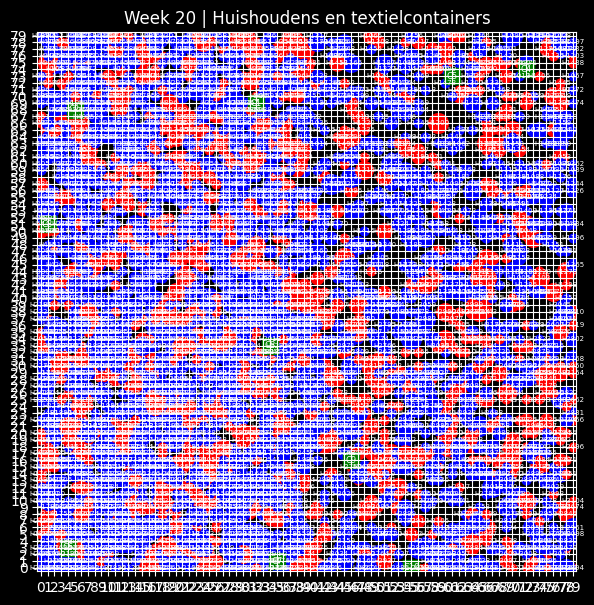

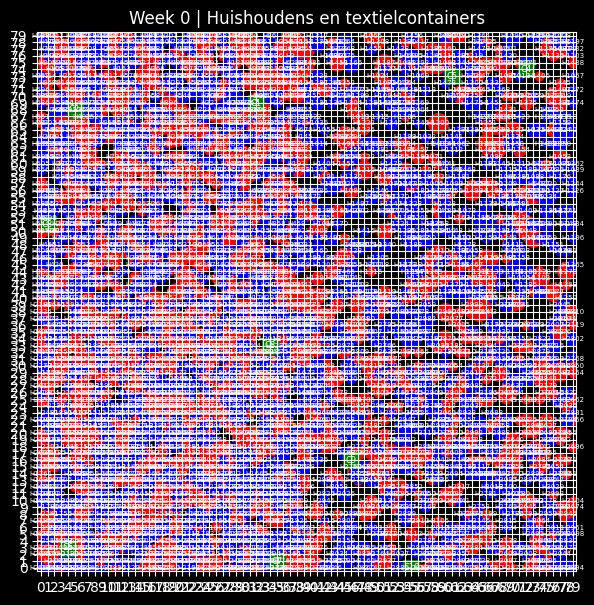

KeyboardInterrupt: 

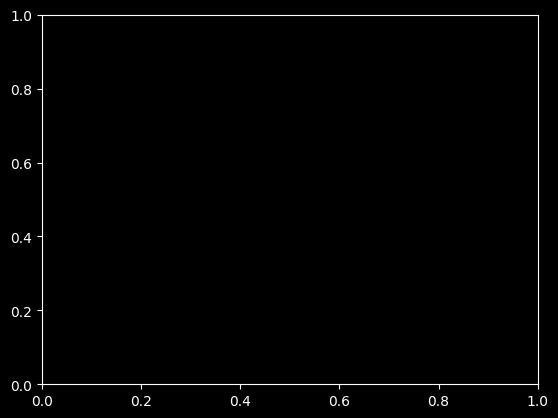

In [72]:
### 4 scenario's uitwerken voor 2 variabelen: inkomen en bevolkingsdichtheid
# 1. Rijke wijk, centrum stad:
#       Relatief hoger inkomen, hogere bevolkingsdichtheid (meer contacten, betere toegang tot recyclingfaciliteiten).
# 2. Rijke wijk, rand stad:
#       Relatief hoger inkomen, lagere bevolkingsdichtheid (minder sociale druk, mogelijk minder nabijheid van faciliteiten).
# 3. Arme wijk, centrum stad:
#       Relatief lager inkomen, hogere bevolkingsdichtheid (sociale druk kan groter zijn).
# 4. Arme wijk, rand stad:
#       Relatief lager inkomen, lagere bevolkingsdichtheid (minder sociale druk, minder toegang tot voorzieningen).

# https://denhaag.incijfers.nl/viewer/?workspace_guid=0200e635-6223-4e40-953c-ace9878cd906

import math
import random
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


# ============================================================
# AGENT: HUISHOUDEN
# ============================================================
class Huishouden(Agent):
    """
    Een huishouden is een agent die de volgende parameters bevat: (huishoudgrootte, opbouwen van textielafval, wordt beïnvloed door buren, recyclewaarde, brengt textiel weg naar dichtsbijzijnde container)

    """

    def __init__(self, unique_id, model, wijk=None, wijk_inkomen_profiel=None, wijk_dichtheid=None):
        super().__init__(unique_id, model)

        self.wijk = wijk
        self.wijk_inkomen_profiel = wijk_inkomen_profiel
        self.wijk_dichtheid = wijk_dichtheid

        # elk huishouden krijgt een basis recyclewaarde, deze waarde bepaald of een huishouden in het begin al recycelt of niet. Deze waarde ligt tussen 0 en 1, wij hebben nu de drempelwaarde even op 0.5 gezet.
        self.basis_recyclewaarde = min(1, max(0, self.model.random.normalvariate(0.5, 0.15)))

        # De actuele recyclewaarde van een huishouden wordt elke stap opnieuw berekend.
        self.recyclewaarde = self.basis_recyclewaarde

        # Aantal directe buren dat meetelt in de buurinvloed.
        self.sociale_gevoeligheid = 0

        # Recyclet het huishouden op dit moment wel of niet
        self.recyclegedrag = False

        # Maakt duidelijk of een huishouden wel of niet recycelt.
        self.status = "recyclet_niet"

        # Verdeling opleidingsniveau naar waarden van CBS
        self.opleidingsniveau = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.262, 0.372, 0.366])[0]

        # Verdeling inkomen wijkafhankelijk
        if self.wijk_inkomen_profiel == "hoog":
            self.inkomen = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.05, 0.35, 0.60])[0]
        elif self.wijk_inkomen_profiel == "laag":
            self.inkomen = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.45, 0.40, 0.15])[0]
        else:
            self.inkomen = self.model.random.choices(["laag", "midden", "hoog"], weights=[0.140, 0.556, 0.304])[0]

        ###########################################################################################
        # Ik heb hier nu iets staan met hoe belangrijk mensen in Nederland het gemiddeld vinden dat de overheid zich bemoeit met het verbeteren van recyclegedrag (volgzaamheid_overheid). Ik neem aan dat dit overeenkomt met de mate waarin deze mensen hun gedrag positief aanpassen door campagne vanuit de overheid over recyclegedrag.
        # volgzaamheid_overheid bepaald hoe sterk campagne_intensiteit (parameter gelijk voor alle huishoudens) de recyclewaarde van een huishouden beïnvloed.

        self.volgzaamheid_overheid = \
        self.model.random.choices(['belangrijk', 'neutraal', 'onbelangrijk'], weights=[0.847, 0.113, 0.04])[0]

        # Verdeling huishoudgrootte naar waarden van CBS
        self.huishoudgrootte = self.model.random.choices(
            [1, 2, 3, 4, 5],
            weights=[55, 26, 9, 7, 3]
        )[0]

        # Basis textielafval:
        # 0,23 kg per persoon per week.
        # Omdat 1 tijdstap = 4 weken, vermenigvuldigen we met 4.
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4

        # Hoeveel textiel een huishouden momenteel opgespaard heeft.
        self.opgespaard_textielafval = 0

        # Weggooifrequentie in weken.
        # Dit geeft aan na hoeveel weken een huishouden zijn opgespaard textiel wegbrengt.
        self.weggooifrequentie = max(1, round(self.model.random.normalvariate(20, 15)))
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie op hoeveelheid textielafval van een huishouden op basis van inkomen.
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.6
        elif self.inkomen == "midden":
            self.textielafval_per_tijdstap *= 1.0
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.7

        # Afstand tot dichtstbijzijnde container.
        self.afstand = None

        # Houdt bij hoeveel kg dit huishouden in totaal opgeslagen heeft.
        self.totaal_opgeslagen = 0

        # Houdt bij hoeveel kg dit huishouden in totaal gerecycled heeft.
        self.totaal_gerecycled = 0

    def update_recyclegedrag(self):
        # Start telkens opnieuw vanaf de vaste basisneiging.
        self.recyclewaarde = self.basis_recyclewaarde

        # Haal buurinvloed op uit het model.
        aantal_buren, buurinvloed = self.model.bereken_buurinvloed(self)
        self.sociale_gevoeligheid = aantal_buren

        # Bepaal dichtstbijzijnde container en afstand.
        container, afstand = self.model.dichtstbijzijnde_container(self)
        self.afstand = afstand

        # Invloed van buren op eigen recyclegedrag.
        self.recyclewaarde += buurinvloed

        # Afstand tot de dichtstbijzijnde container is van invloed op de kans op recycling (recyclewaarde).
        # De maximale afstand die een actor kan lopen is lengte+breedte aan hokjes
        max_afstand = (self.model.grid.width - 1) + (self.model.grid.height - 1)
        rel_afstand = afstand / max_afstand

        # Correctie op recyclewaarde van een huishouden op basis van afstand tot dichtstbijzijnde container.
        # - Kleinere afstand, grotere kans op recycling -> kleine positieve correctie
        # - Gemiddelde afstand -> geen correctie
        # - Grotere afstand, kleinere kans op recycling -> kleine negatieve correctie
        if rel_afstand <= 0.2:
            self.recyclewaarde += 0.05
        elif rel_afstand <= 0.4:
            self.recyclewaarde += 0.00
        elif rel_afstand <= 0.6:
            self.recyclewaarde -= 0.05
        else:
            self.recyclewaarde -= 0.10

        # Correctie op recyclewaarde van een huishouden op basis van inkomen (volgens Viscusi, Huber & Bell (2023))
        # - hoog inkomen: ongeveer -1%
        # - laag inkomen: ongeveer -3%
        if self.inkomen == "hoog":
            self.recyclewaarde -= 0.01
        elif self.inkomen == "laag":
            self.recyclewaarde -= 0.03

        # Correctie op recyclewaarde van een huishouden op basis van opleidingsniveau
        # BRON: Lorincová, S., & Osvaldová, M. (2025). Pro-Environmental Behavior and Attitudes Towards Recycling in Slovak Republic. Recycling, 10(4), 159. https://doi.org/10.3390/recycling10040159
        # - hoog opleidingsniveau: ongeveer +6%
        # - midden opleidingsniveau: ongeveer -4%
        # - laag opleidingsniveau: ongeveer -6%
        if self.opleidingsniveau == "hoog":
            self.recyclewaarde += 0.06
        elif self.opleidingsniveau == "midden":
            self.recyclewaarde -= 0.04
        elif self.opleidingsniveau == "laag":
            self.recyclewaarde -= 0.06
        # Zorg dat de waarde netjes tussen 0 en 1 blijft.
        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Correctie op recyclewaarde van een huishouden op basis van volgzaamheid & campagne_intensiteit (CBS, 2020)
        # - Belangrijk: Sterkere invloed
        # - Neutraal: Matige invloed
        # - Onbelangrijk: Zwakke invloed
        campagne_invloed = 0
        if self.volgzaamheid_overheid == 'belangrijk':
            campagne_invloed = self.model.campagne_intensiteit * 0.05
        elif self.volgzaamheid_overheid == 'neutraal':
            campagne_invloed = self.model.campagne_intensiteit * 0.03
        elif self.volgzaamheid_overheid == 'onbelangrijk':
            campagne_invloed = self.model.campagne_intensiteit * 0.01
        self.recyclewaarde += campagne_invloed
        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Drempelwaarde: vanaf 0.5 recyclet het huishouden.
        self.recyclegedrag = self.recyclewaarde >= self.model.drempel

        # Tekststatus voor interpretatie en visualisatie.
        if self.recyclegedrag:
            self.status = "recyclet"
        else:
            self.status = "recyclet_niet"

    def produceer_textiel(self):
        """
        Voegt per stap nieuw textielafval toe aan het huishouden.
        """
        self.opgespaard_textielafval += self.textielafval_per_tijdstap
        self.totaal_opgeslagen += self.textielafval_per_tijdstap
        self.model.geproduceerd_deze_stap += self.textielafval_per_tijdstap

    def probeer_textiel_weg_te_brengen(self):
        """
        Als het huishouden aan de beurt is om textiel weg te brengen:
        - en het recyclet, dan gaat het textiel naar de dichtstbijzijnde container
        - wat niet in de container past, wordt geregistreerd als niet gerecycled door capaciteitsgebrek
        - als het huishouden niet recyclet, verdwijnt het uit het systeem als niet gerecycled
        Daarna wordt het opgespaarde textiel leeggemaakt en de teller opnieuw ingesteld.
        """
        if self.weken_tot_weggooien <= 0:
            aangeboden_hoeveelheid = self.opgespaard_textielafval
            self.model.aangeboden_deze_stap += aangeboden_hoeveelheid

            if self.recyclegedrag:
                container, _ = self.model.dichtstbijzijnde_container(self)

                # Beschikbare ruimte in de container
                ruimte_over = max(0, container.capaciteit - container.vulgraad)

                # Deel dat echt gerecycled kan worden
                hoeveelheid_te_recyclen = min(ruimte_over, aangeboden_hoeveelheid)

                # Deel dat niet meer in de container past
                hoeveelheid_niet_gerecycled_door_capaciteit = aangeboden_hoeveelheid - hoeveelheid_te_recyclen

                # Voeg gerecycled deel toe aan container
                container.vulgraad += hoeveelheid_te_recyclen

                # Houd modeluitkomsten bij
                self.totaal_gerecycled += hoeveelheid_te_recyclen
                self.model.gerecycled_deze_stap += hoeveelheid_te_recyclen
                self.model.niet_gerecycled_door_capaciteit_deze_stap += hoeveelheid_niet_gerecycled_door_capaciteit

                # Per huishoudgrootte
                self.model.gerecycled_per_huishoudgrootte[self.huishoudgrootte] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid

                # Per inkomen
                self.model.gerecycled_per_huishoudinkomen[self.inkomen] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid

                # Per opleidingsniveau
                self.model.gerecycled_per_opleidingsniveau[self.opleidingsniveau] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

            else:
                # Huishouden biedt wel textiel aan, maar recyclet niet
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

            # Alles is uit huis verdwenen: niets wordt bewaard
            self.opgespaard_textielafval = 0

            # Teller opnieuw instellen
            self.weken_tot_weggooien = self.weggooifrequentie

    def step(self):
        """
        Eén stap van een huishouden:
        1. textiel produceren
        2. tijd tot weggooien verlagen
        3. recyclegedrag opnieuw berekenen
        4. eventueel textiel wegbrengen
        """
        self.produceer_textiel()
        self.weken_tot_weggooien -= 4
        self.update_recyclegedrag()
        self.probeer_textiel_weg_te_brengen()


# ============================================================
# AGENT: CONTAINER
# ============================================================
class Container(Agent):
    """
    Een textielcontainer heeft:
    - een maximale capaciteit
    - een actuele vulgraad
    - een methode om geleegd te worden
    """

    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        # Capaciteit in kg. (5m^3 * 150 kg/m^3)
        self.capaciteit = 750

        # Huidige hoeveelheid textiel in de container.
        self.vulgraad = 0

        ###############################################################################################################################
        # Iedere 8 weken wordt de container geleegd. (nu tijdelijk 52 weken)
        self.ledigingsfrequentie = 52

    def ledigen(self):
        """
        Zet de vulgraad terug op 0.
        """
        self.vulgraad = 0


# ============================================================
# MODEL: STAD
# ============================================================
class Stad(Model):
    """
    Het model bevat:
    - een grid met huishoudens en containers
    - logica voor buurinvloed en afstand
    - een centrale stapfunctie
    - opslag van resultaten voor grafieken
    """

    ###
    def __init__(self, width=80, height=80, campagne_intensiteit=1.0, seed=42):
        super().__init__()

        # Gebruik de randomgenerator van het model,
        # zodat simulaties reproduceerbaar zijn.
        self.random.seed(seed)

        # Het grid van de stad.
        self.grid = MultiGrid(width, height, torus=False)

        # Lijsten met agents.
        self.huishoudens = []
        self.containers = []

        # Interne ID-teller.
        self.id = 0

        # Tijd in weken.
        self.week = 0

        # Drempelwaarde voor recyclen.
        self.drempel = 0.5

        # Campagnevoering textielrecycling vanuit de overheid (modelparameter)
        self.campagne_intensiteit = campagne_intensiteit

        # Vier scenario-wijken
        self.wijken = {
            "rijk_centrum": {
                "inkomen_profiel": "hoog",
                "dichtheid": "hoog",
                "aantal_huishoudens": 1000,
                "aantal_containers": 3
            },
            "rijk_rand": {
                "inkomen_profiel": "hoog",
                "dichtheid": "laag",
                "aantal_huishoudens": 500,
                "aantal_containers": 2
            },
            "arm_centrum": {
                "inkomen_profiel": "laag",
                "dichtheid": "hoog",
                "aantal_huishoudens": 1100,
                "aantal_containers": 3
            },
            "arm_rand": {
                "inkomen_profiel": "laag",
                "dichtheid": "laag",
                "aantal_huishoudens": 600,
                "aantal_containers": 2
            }
        }

        # Variabelen die per stap opnieuw worden gevuld.
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        # Resultaten doorheen de tijd.
        self.geschiedenis_weken = [0]
        self.geproduceerd_per_stap = [0]
        self.aangeboden_per_stap = [0]
        self.gerecycled_per_stap = [0]
        self.niet_gerecycled_door_capaciteit_per_stap = [0]
        self.percentage_gerecycled_van_aangeboden_per_stap = [0]
        self.percentage_huishoudens_dat_recyclet = [0]
        self.geschiedenis_container_vulgraden = []

        # Uitkomsten per huishoudgrootte.
        self.aangeboden_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudinkomen = {"laag": 0, "midden": 0, "hoog": 0}
        self.aangeboden_per_huishoudinkomen = {"laag": 0, "midden": 0, "hoog": 0}
        self.aangeboden_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}
        self.gerecycled_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}

        midden_x = width // 2
        midden_y = height // 2

        wijk_posities = {
            "rijk_centrum": [(x, y) for x in range(0, midden_x) for y in range(midden_y, height)],
            "rijk_rand": [(x, y) for x in range(midden_x, width) for y in range(midden_y, height)],
            "arm_centrum": [(x, y) for x in range(0, midden_x) for y in range(0, midden_y)],
            "arm_rand": [(x, y) for x in range(midden_x, width) for y in range(0, midden_y)],
        }

        for wijknaam, info in self.wijken.items():
            mogelijke_posities = wijk_posities[wijknaam][:]
            nodig = info["aantal_huishoudens"] + info["aantal_containers"]

            if nodig > len(mogelijke_posities):
                raise ValueError(f"Te veel agents voor wijk {wijknaam}")

            gekozen_posities = self.random.sample(mogelijke_posities, nodig)

            container_posities = gekozen_posities[:info["aantal_containers"]]
            huishouden_posities = gekozen_posities[info["aantal_containers"]:]

            # Plaats containers
            for pos in container_posities:
                c = Container(self.next_id(), self)
                c.wijk = wijknaam
                self.grid.place_agent(c, pos)
                self.containers.append(c)

            # Plaats huishoudens
            for pos in huishouden_posities:
                h = Huishouden(
                    self.next_id(),
                    self,
                    wijk=wijknaam,
                    wijk_inkomen_profiel=info["inkomen_profiel"],
                    wijk_dichtheid=info["dichtheid"]
                )
                self.grid.place_agent(h, pos)
                self.huishoudens.append(h)

        # Eerste berekening van gedrag.
        for huishouden in self.huishoudens:
            huishouden.update_recyclegedrag()

        # Startwaarden voor containergeschiedenis.
        self.geschiedenis_container_vulgraden.append(
            [container.vulgraad for container in self.containers]
        )

    def next_id(self):
        """
        Geeft elke agent een uniek ID.
        """
        self.id += 1
        return self.id

    def manhattan_afstand(self, pos1, pos2):
        """
        Bereken Manhattan-afstand tussen twee posities op het grid.
        """
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def dichtstbijzijnde_container(self, huishouden):
        """
        Zoek de dichtstbijzijnde container voor een huishouden.
        Geeft zowel de container als de afstand terug.
        """
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    def bereken_buurinvloed(self, huishouden):
        """
        Bereken buurinvloed op basis van de 4 directe buren.
        - +0.1 per buur die recyclet
        - -0.1 per buur die niet recyclet
        """
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [
            (x - 1, y),  # links
            (x + 1, y),  # rechts
            (x, y - 1),  # onder
            (x, y + 1)  # boven
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        if agent.recyclegedrag:
                            buurinvloed += 0.05
                        else:
                            buurinvloed -= 0.05

        return aantal_buren, buurinvloed

    def verzamel_resultaten(self):
        """
        Sla per stap de belangrijkste resultaten op,
        zodat die later geplot kunnen worden.
        """
        self.geschiedenis_weken.append(self.week)
        self.geproduceerd_per_stap.append(self.geproduceerd_deze_stap)
        self.aangeboden_per_stap.append(self.aangeboden_deze_stap)
        self.gerecycled_per_stap.append(self.gerecycled_deze_stap)
        self.niet_gerecycled_door_capaciteit_per_stap.append(self.niet_gerecycled_door_capaciteit_deze_stap)

        # Percentage gerecycled in deze stap.
        if self.aangeboden_deze_stap > 0:
            percentage = (self.gerecycled_deze_stap / self.aangeboden_deze_stap) * 100
        else:
            percentage = 0
        self.percentage_gerecycled_van_aangeboden_per_stap.append(percentage)

        # Percentage huishoudens dat op dat moment recyclet.
        aantal_recyclers = sum(1 for h in self.huishoudens if h.recyclegedrag)
        percentage_recyclers = (aantal_recyclers / len(self.huishoudens)) * 100
        self.percentage_huishoudens_dat_recyclet.append(percentage_recyclers)

        # Sla container-vulgraden op.
        self.geschiedenis_container_vulgraden.append([container.vulgraad for container in self.containers])

    def step(self):
        """
        Eén modelstap:
        1. Tijd vooruit zetten met 4 weken
        2. Stap van elk huishouden uitvoeren
        3. Containers legen indien nodig
        4. Resultaten opslaan
        """
        self.week += 4

        # Reset stapvariabelen.
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        # Laat elk huishouden zijn eigen gedrag uitvoeren.
        for huishouden in self.huishoudens:
            huishouden.step()

        # Ledig alle containers volgens de ingestelde frequentie.
        if self.containers and self.week % self.containers[0].ledigingsfrequentie == 0:
            for container in self.containers:
                container.ledigen()

        # Verzamel resultaten voor grafieken.
        self.verzamel_resultaten()

    def visualiseer(self, ax=None):
        """
        Teken het grid.
        - Blauwe huishoudens recyclen
        - Rode huishoudens recyclen niet
        - Groene vierkanten zijn containers
        - Grootte van de huishoudensymbolen hangt af van huishoudgrootte
        """
        if ax is None:
            plt.figure(figsize=(7, 7))
            ax = plt.gca()
        else:
            ax.clear()

        # Huishoudens tekenen.
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            grootte_bol = h.huishoudgrootte * 40
            ax.scatter(x, y, color=kleur, s=grootte_bol)
            ax.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        # Containers tekenen.
        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            ax.scatter(x, y, color="green", s=120, marker="s")
            ax.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        # Layout.
        ax.grid()
        ax.set_title(f"Week {self.week} | Huishoudens en textielcontainers")
        ax.set_xlim(-0.5, self.grid.width - 0.5)
        ax.set_ylim(-0.5, self.grid.height - 0.5)
        ax.set_xticks(range(self.grid.width))
        ax.set_yticks(range(self.grid.height))
        ax.set_aspect("equal")

        if ax is plt.gca():
            plt.show()

    def resultaten(self):
        """
        Print een overzicht van de huidige toestand van elk huishouden.
        """
        print("\nRESULTATEN:\n")

        print(
            f"{'Huishouden':<12} {'Grootte':<8} {'Positie':<12} {'Buren':<6} "
            f"{'Inkomen':<10}  {'Afstand':<10} "
            f"{'Opgespaard':<12} {'Recyclewaarde':<16} {'Status':<18}"
        )
        print("-" * 130)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{huishouden.huishoudgrootte:<8} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.opgespaard_textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{huishouden.status:<18}"
            )

    # ========================================================
    # GRAFIEKEN
    # ========================================================

    def plot_totale_kg_opgeslagen_vs_gerecycled(self):
        """
        Relevante grafiek 1:
        laat per stap zien hoeveel textiel opgeslagen en gerecycled is.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.geproduceerd_per_stap, marker="o", label="Geproduceerd (kg)")
        plt.plot(self.geschiedenis_weken, self.aangeboden_per_stap, marker="o", label="Aangeboden (kg)")
        plt.plot(self.geschiedenis_weken, self.gerecycled_per_stap, marker="o", label="Gerecycled (kg)")
        plt.xlabel("Week")
        plt.ylabel("Textiel (kg)")
        plt.title("Geproduceerde, aangeboden en gerecyclede hoeveelheid textiel per stap")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_percentage_gerecycled_over_tijd(self):
        """
        Relevante grafiek 2:
        laat zien welk percentage van het opgeslagen textiel gerecycled wordt.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_gerecycled_van_aangeboden_per_stap, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage van aangeboden textiel dat gerecycled wordt")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_percentage_huishoudens_dat_recyclet(self):
        """
        Relevante grafiek 3:
        laat zien welk aandeel van de huishoudens op een bepaald moment recyclet.
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_huishoudens_dat_recyclet, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Huishoudens die recyclen (%)")
        plt.title("Percentage huishoudens dat recyclet over tijd")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_container_vulgraden(self):
        """
        Relevante grafiek 4:
        toont hoe de vulgraad van elke container evolueert.
        """
        plt.figure(figsize=(12, 6))

        for i in range(len(self.containers)):
            vulgraden_i = [stap[i] for stap in self.geschiedenis_container_vulgraden]
            plt.plot(self.geschiedenis_weken, vulgraden_i, marker="o", label=f"Container {i + 1}")

        plt.xlabel("Week")
        plt.ylabel("Vulgraad (kg)")
        plt.title("Vulgraad van elke container over tijd")
        plt.ylim(0, 750)
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 5:
        deze grafiek past heel goed bij jouw onderzoeksvraag.
        Ze laat zien hoeveel kg textiel gerecycled werd per huishoudgrootte.
        """
        groottes = list(self.gerecycled_per_huishoudgrootte.keys())
        waarden = list(self.gerecycled_per_huishoudgrootte.values())

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, waarden)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Totaal gerecycled textiel (kg)")
        plt.title("Totaal gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_huishoudgrootte(self):
        """
        Relevante grafiek 6:
        toont per huishoudgrootte welk percentage van het opgeslagen textiel gerecycled werd.
        Dit is inhoudelijk heel relevant voor jouw onderzoek.
        """
        groottes = [1, 2, 3, 4, 5]
        percentages = []

        for grootte in groottes:
            aangeboden = self.aangeboden_per_huishoudgrootte[grootte]
            gerecycled = self.gerecycled_per_huishoudgrootte[grootte]

            if aangeboden > 0:
                percentages.append((gerecycled / aangeboden) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, percentages)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per huishoudgrootte")
        plt.xticks(groottes)
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_inkomen(self):
        """
        Toont per inkomenscategorie welk percentage van het opgeslagen
        textiel gerecycled werd.
        """
        inkomens = ["laag", "midden", "hoog"]
        percentages = []

        for inkomen in inkomens:
            aangeboden = self.aangeboden_per_huishoudinkomen[inkomen]
            gerecycled = self.gerecycled_per_huishoudinkomen[inkomen]

            if aangeboden > 0:
                percentages.append((gerecycled / aangeboden) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(inkomens, percentages)
        plt.xlabel("Inkomenscategorie")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per inkomenscategorie")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_opleidingsniveau(self):
        """
        Toont per opleidingsniveau welk percentage van het opgeslagen
        textiel gerecycled werd.
        """
        niveaus = ["laag", "midden", "hoog"]
        percentages = []

        for niveau in niveaus:
            aangeboden = self.aangeboden_per_opleidingsniveau[niveau]
            gerecycled = self.gerecycled_per_opleidingsniveau[niveau]

            if aangeboden > 0:
                percentages.append((gerecycled / aangeboden) * 100)
            else:
                percentages.append(0)

        plt.figure(figsize=(10, 6))
        plt.bar(niveaus, percentages)
        plt.xlabel("Opleidingsniveau")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per opleidingsniveau")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()


# ============================================================
# MODEL DRAAIEN   [DEN HAAG]
# ============================================================

# Maak één model aan

model = Stad(width=80, height=80, seed=42)

# Draai de simulatie voor 20 stappen.
for _ in range(5):
    model.step()

# Print enkele samenvattende resultaten.
totaal_geproduceerd = sum(model.geproduceerd_per_stap)
totaal_aangeboden = sum(model.aangeboden_per_stap)
totaal_gerecycled = sum(model.gerecycled_per_stap)

if totaal_aangeboden > 0:
    totaal_percentage = (totaal_gerecycled / totaal_aangeboden) * 100
else:
    totaal_percentage = 0

print("SAMENVATTING")
print("-" * 40)
print(f"Totaal geproduceerd textiel: {totaal_geproduceerd:.2f} kg")
print(f"Totaal aangeboden textiel:   {totaal_aangeboden:.2f} kg")
print(f"Totaal gerecycled textiel:   {totaal_gerecycled:.2f} kg")
print(f"Percentage gerecycled van aangeboden textiel: {totaal_percentage:.2f}%")

# Optioneel: huidige toestand van alle huishoudens afdrukken.
model.resultaten()

# ============================================================
# VISUALISATIE VAN HET EINDRESULTAAT
# ============================================================
model.visualiseer()

# ============================================================
# ANIMATIE
# ============================================================

# Voor de animatie maken we een nieuw model,
# zodat de animatie netjes vanaf week 0 start.
model_animatie = Stad(width=80, height=80, seed=42)

fig, ax = plt.subplots(figsize=(7, 7))
model_animatie.visualiseer(ax)


def update(frame):
    """
    Updatefunctie voor de animatie.
    Bij elk frame draait het model één stap verder.
    """
    model_animatie.step()
    model_animatie.visualiseer(ax)


anim = FuncAnimation(
    fig,
    update,
    frames=20,
    interval=1000,
    repeat=False,
    cache_frame_data=False
)

display(HTML(anim.to_jshtml()))
plt.close(fig)

# ============================================================
# GRAFIEKEN
# ============================================================
model.plot_totale_kg_opgeslagen_vs_gerecycled()
model.plot_percentage_gerecycled_over_tijd()
model.plot_percentage_huishoudens_dat_recyclet()
model.plot_container_vulgraden()
model.plot_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_inkomen()
model.plot_percentage_gerecycled_per_opleidingsniveau()